In [ ]:
#%pip install python-dotenv

# 0. Environment Setting

In [ ]:
import sys
import os
import arcpy
import atexit
import re
from dotenv import load_dotenv, find_dotenv

from pathlib import Path
load_dotenv(find_dotenv())

# Set the workspace environment to the parent folder containing both geodatabases
aprx_path = os.environ.get('APRX')
arcpy.env.workspace = os.environ.get('workspace_path')
print(f"aprx_path: {aprx_path}")
print(f"arcpy.env.workspace: {arcpy.env.workspace}")

# Global path variables
global workspace_path
global aprx_path

global default_gdb
global current_qt_gdb
global official_accumulated_gdb

global current_qt_group_point
global current_qt_group_polygon

global ssheet

## 0.1. Env: Global Variables

In [ ]:
# 노트북 초기화 셀
import arcpy

aprx = arcpy.mp.ArcGISProject("CURRENT")

# 작업 대상 맵 명시적 지정
TARGET_MAP_NAME = "AR_EbA_Area"

map_obj = None
for m in aprx.listMaps():
    if m.name == TARGET_MAP_NAME:
        map_obj = m
        break

assert map_obj is not None, f"Mapa '{TARGET_MAP_NAME}' no encontrado"
print(f"Trabajando con mapa: {map_obj.name}")

In [ ]:
# 1.0. Collecting: Specify the target group layers
current_qt_group_point = "2026_Q1_v3_point" # Add or change to your target group layer names
current_qt_group_polygon = "2026_Q1_v3_polygon"  # Add or change to your target group layer names
current_qt = "PPD_Final"
prev_qt = "2026_Q1_v2"

# 2.0. Initial reporting: Set newest Smartsheet data from `AR_Ssheet_to_ArcGIS.ipynb`
ssheet_name = "Ss_mrg_tbl_202604161402"

In [ ]:
# Define paths to the geodatabases for current quarter and official accumulated data
default_gdb = os.path.join(arcpy.env.workspace, "p30", "default.gdb")
current_qt_gdb = os.path.join(arcpy.env.workspace, "AR_Quarterly_Partial.gdb")
official_accumulated_gdb = os.path.join(arcpy.env.workspace, "AR_Oficial_Acumulado.gdb")

# Update the ssheet path - use the correct path construction
ssheet = os.path.join(default_gdb, ssheet_name)

# 1.3. Merge by shape type: Define paths to the feature classes within the respective geodatabases
current_merged_point = f"{current_qt_gdb}\\T{current_qt_group_point}"
current_merged_polygon = f"{current_qt_gdb}\\T{current_qt_group_polygon}"

# 2.0. Initial reporting: Define the output location for the count overlap results within the current quarter geodatabase
current_merged_polygon_count_ovlp = f"{current_qt_gdb}\\T{current_qt_group_polygon}_CountOverlapp"
current_merged_polygon_count_ovlp_PairInt = f"{current_qt_gdb}\\T{current_qt_group_polygon}_CountOverlapp_PairIntersect"

# 3.0. Modifying for overlap polygon: Define paths to the feature classes within the respective geodatabases
AR_Oficial_punto_GTM = "AR_oficial_puntos_Q4_2025_130426_GP_Rev"
AR_Oficial_poligono_GTM = "AR_oficial_poligonos_Q4_2025_130426_GP"
official_point = "AR_oficial_puntos_Q4_2025_130426_GP_Rev"
official_polygon = "AR_oficial_poligonos_Q4_2025_130426_GP"

#AR_Oficial_punto_GTM = "AR_Oficial_punto_GTM"
#AR_Oficial_poligono_GTM = "AR_Oficial_poligono_GTM"
#official_point = f"{official_accumulated_gdb}\\{AR_Oficial_punto_GTM}"
#official_polygon = f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}"



# 3. Modifying: Erase Tool (will be copied from the countOverlapp_pariIntersect and its selection using attribute by 'Erase_FC' domain(column) value)
erase_tool_layer = f"{current_qt_gdb}\\T{current_qt_group_polygon}_CountOverlapp_PairIntersect_Erase_tool"

# 3. Modifying: OUTPUT FCs after excute Erase tool
AR_Oficial_poligono_GTM_Erased =f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}_{current_qt_group_polygon}_Erased"
current_merged_polygon_Erased = f"{current_qt_gdb}\\T{current_qt_group_polygon}_Erased"
current_merged_polygon_Erased_pair_mico = f"{current_qt_gdb}\\T{current_qt_group_polygon}_Erased_pair_micro"

# 3. Modifying: backup_erased fc before excute area calculation
AR_Oficial_poligono_GTM_Erased_backup = f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}_{current_qt_group_polygon}_Erased_backup"


# 3. Modifying: Create feature layers from the feature class paths: Variables as layer.name
in_lyr_current = f"T{current_qt_group_polygon}_Erased"
in_lyr_official = f"AR_Oficial_poligono_GTM_{current_qt_group_polygon}_Erased"
slct_lyr = f"T{current_qt_group_polygon}_CountOverlapp_PairIntersect"

# 4. Updating: Updating erased current data with microcuenca, municipality information using pairwiseintersect so each polygon could be seperated by micro * muni
current_merged_polygon_Erased_pair_mico = f"{current_qt_gdb}\\T{current_qt_group_polygon}_Erased_pair_micro"
BASE_Micro_MUNI_FC = "BASE_4_MUNI_WF_PairwiseInter_NOdelete"
BASE_Micro_MUNI = f"{default_gdb}\\{BASE_Micro_MUNI_FC}"

Current_point_cleaned = current_merged_point
Current_point_cleaned_pair_micro = f"{current_qt_gdb}\\T{current_qt_group_point}_cleaned_pair_micro"

official_point_prev_qt_backup = f"{official_accumulated_gdb}\\{AR_Oficial_punto_GTM}_{prev_qt}_point_backup"
official_polygon_prev_qt_backup = f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}_{prev_qt}_polygon_backup"

official_point_current_qt_backup = f"{official_accumulated_gdb}\\{AR_Oficial_punto_GTM}_{current_qt}_point"
official_polygon_current_qt_backup = f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}_{current_qt}_polygon"

# 5. after Appending, need to update AbE_ENG
list_updating_abe_eng = [Current_point_cleaned_pair_micro, official_point, current_merged_polygon_Erased_pair_mico, AR_Oficial_poligono_GTM_Erased, official_polygon]
list_updating_abe_eng_Oficial_Erased = [AR_Oficial_poligono_GTM_Erased]

# 6. Export table
export_table_polygon = f"{official_accumulated_gdb}\\AR_Official_{current_qt_group_polygon}_table"
export_table_point = f"{official_accumulated_gdb}\\AR_Official_{current_qt_group_point}_table"
export_table_merged = f"{official_accumulated_gdb}\\AR_Official_{current_qt}_merged_table"

In [ ]:
# Debug print statements
print(f"arcpy.env.workspace: {arcpy.env.workspace}")
print(f"default_gdb: {default_gdb}")
print(f"ssheet_name: {ssheet_name}")
print(f"ssheet: {ssheet}")

print(f"accumulado_gdb: {official_accumulated_gdb}")

# Check if default_gdb exists
if os.path.exists(default_gdb):
    print(f"Default GDB exists: {default_gdb}")
else:
    print(f"Default GDB does not exist: {default_gdb}")

## 0.2 Setup Environment & Get the Current Map Object

In [ ]:
def setup_environment():
    """Sets up the arcpy environment for use in scripts using global paths."""
    try:
        arcpy.env.workspace = os.environ.get('workspace_path')
        arcpy.env.overwriteOutput = True
        atexit.register(arcpy.ClearWorkspaceCache_management)
        print("Environment set up with workspace:", arcpy.env.workspace)
    except Exception as e:
        print("Failed to set up environment:", e)

def get_map_object(map_name): # replace map name as active map on your arcgis project
    """Retrieves a map object from the global APRX path."""
    try:
        aprx = arcpy.mp.ArcGISProject("CURRENT")
        map_obj = aprx.listMaps(map_name)[0]
        return map_obj
    except Exception as e:
        print("Failed to retrieve map object:", e)
        return None

# Setup environment and get the map object
setup_environment()
map_obj = get_map_object(os.environ.get('AR_MAP_NAME'))
if map_obj:
    print("Map object retrieved successfully.")
else:
    print("Failed to retrieve map object.")


In [ ]:
# get group layer name
# Iterate through the layers
for layer in map_obj.listLayers():
    # Check if the layer is a group layer
    if layer.isGroupLayer:
        print(f"Group Layer Name: {layer.name}")


# 1. Collecting

## 1.1. Prepare Workspace

### 1.1.1. Create New Group Layer in ArcGIS Pro

- Format:
```python
  (Parent Group Layer) YYYY_Q#
  (Sub-Point Group Layer) YYYY_Q#_point
  (Sub-Polygon Group Layer) YYYY_Q#_polygon
  
```

### 1.1.2. Function to Get Feature Layer Names in a Specified Group:
> * Shape order: point -> polygon
> * Quarter order: current -> official

In [ ]:
def get_feature_layers(group_name, map):
    """Get names of feature layers in a specified group layer."""
    feature_layers = []
    seen = set()
    for layer in map.listLayers():
        if layer.isGroupLayer and layer.name == group_name:
            print(f"Processing group layer: {layer.name}")
            for sublayer in layer.listLayers():
                if sublayer.isFeatureLayer:
                    try:
                        data_source = sublayer.dataSource
                        if data_source not in seen:
                            seen.add(data_source)
                            print(f"Found feature layer: {sublayer.name}")
                            feature_layers.append(data_source)
                        else:
                            print(f"Skipping duplicate: {sublayer.name}")
                    except AttributeError:
                        print(f"Layer {sublayer.name} does not have a dataSource attribute.")
    return feature_layers

feature_layers_point = get_feature_layers(current_qt_group_point, map_obj)
feature_layers_polygon = get_feature_layers(current_qt_group_polygon, map_obj)

if not feature_layers_point:
    print(f"No feature layers found in group '{current_qt_group_point}'.")

if not feature_layers_polygon:
    print(f"No feature layers found in group '{current_qt_group_polygon}'.")

## 1.2. `point & polygon` layer: Function to Update Field Values: 'CdgActvdd', 'Area_ha' 

### 1.2.1. Add or Update the 'CdgActvdd' field in `point & polygon layers` depends on their layer name. 
* Layer name must be assigned in previous task (when you get shape from Smartsheet)

In [ ]:
def add_field(layer_path, field_name, field_type="TEXT"):
    """Add a new field to a feature layer if it does not already exist."""
    try:
        existing_fields = [f.name for f in arcpy.ListFields(layer_path)]
        print(f"Existing fields in {layer_path}: {existing_fields}")  # Debug output

        if field_name not in existing_fields:
            arcpy.AddField_management(layer_path, field_name, field_type)
            print(f"Added field '{field_name}' to {layer_path}")
        else:
            print(f"Field '{field_name}' already exists in {layer_path}. No action taken.")
    except arcpy.ExecuteError as e:
        print(f"Error adding field '{field_name}': {str(e)}")


        
def update_field_values(layer, field_name, pattern):
    """Update field values based on a regular expression pattern."""
    match = re.search(pattern, layer)
    if match:
        value_to_add = match.group(1)
        with arcpy.da.UpdateCursor(layer, field_name) as cursor:
            for row in cursor:
                row[0] = value_to_add
                cursor.updateRow(row)
        print(f"Updated field '{field_name}' in {layer} with value {value_to_add}")
        
regex_pattern = r"(\d{6}_C\d_[A-ZÓ]{3}_[a-z])"

field_name_cdg = 'CdgActvdd'
field_name_area = 'Area_ha'
field_type_area = 'DOUBLE'

for fl in feature_layers_point:
    add_field(fl, field_name_cdg)  # Add 'CdgActvdd' field if not present
    add_field(fl, field_name_area, field_type_area)  # Add 'Area_ha' field if not present
    update_field_values(fl, field_name_cdg, regex_pattern)  # Update 'CdgActvdd' field based on regex

for fl in feature_layers_polygon:
    add_field(fl, field_name_cdg)  # Same operations for polygon layers
    add_field(fl, field_name_area, field_type_area)
    update_field_values(fl, field_name_cdg, regex_pattern)


### 1.2.2.  `point layers`: Add or Update the 'Area_ha' field: Copy area data from any of area related field to 'Area_ha' filed

In [ ]:
import unicodedata
import arcpy

def normalize(text):
    return unicodedata.normalize('NFKD', text or '') \
                      .encode('ASCII','ignore') \
                      .decode('ASCII') \
                      .lower()

def add_or_update_area_field(feature_layers, new_field_name):
    norm_new = normalize(new_field_name)
    numeric_types = {"Double","Single","Integer","SmallInteger"}

    for layer in feature_layers:
        fields = arcpy.ListFields(layer)
        # 1) ensure the target exists
        if new_field_name not in [f.name for f in fields]:
            arcpy.AddField_management(layer, new_field_name, "DOUBLE")

        # 2) build candidates
        candidates = []
        for f in fields:
            if f.type not in numeric_types:
                continue
            if f.name.lower() == new_field_name.lower():
                continue

            nm = normalize(f.name)
            al = normalize(f.aliasName)

            if (
                "area" in nm
                or nm.endswith("ha")
                or "hectare" in nm
                or "has" in nm
                or "area" in al
                or al.endswith("ha")
                or "hectare" in al
                or "has" in al
            ):
                candidates.append(f.name)

        if not candidates:
            print(f"❌ No area‑candidate found in {layer}")
            continue

        # 3) pick one (e.g. the shortest name)
        source = sorted(candidates, key=len)[0]
        print(f"→ copying from '{source}' into '{new_field_name}' on {layer}")

        # 4) copy values
        with arcpy.da.UpdateCursor(layer, [source, new_field_name]) as cur:
            for row in cur:
                row[1] = round(row[0], 2) if row[0] is not None else None
                cur.updateRow(row)

        print(f"✔ Done {layer}")

# Usage:
add_or_update_area_field(feature_layers_point, new_field_name="Area_ha")


In [ ]:
import unicodedata
import arcpy

def normalize_field_name(name):
    """
    Normalize a field name by removing accents and converting to lowercase.
    :param name: The field name to normalize.
    :return: Normalized field name.
    """
    return unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('ASCII').lower()

def add_or_update_num_bnf_field(feature_layers, bnf_fields, new_field_name):
    """
    Adds a new field 'NumPrclBnf' to the feature layers and copies data from existing numeric beneficiary-related fields.
    If no value is found or the field is not numeric, sets the value to 1.
    :param feature_layers: List of feature layer paths.
    :param bnf_fields: List of possible field names containing beneficiary data.
    :param new_field_name: The name of the new field to create and update.
    """
    # Convert beneficiary field names to normalized lowercase for comparison
    bnf_fields_normalized = [normalize_field_name(field) for field in bnf_fields]

    for layer in feature_layers:
        # Get all fields in normalized lowercase and their properties
        fields_normalized = {normalize_field_name(field.name): field for field in arcpy.ListFields(layer)}
        
        # Check and add the new field
        if normalize_field_name(new_field_name) not in fields_normalized:
            arcpy.AddField_management(layer, new_field_name, "SHORT")

        # Identify the existing numeric beneficiary-related field (normalized)
        existing_bnf_field = next(
            (field.name for field in fields_normalized.values() 
             if field.type in ["SmallInteger", "Integer", "Double", "Single"] 
             and normalize_field_name(field.name) in bnf_fields_normalized),
            None
        )
        
        # Update values in the new field
        if existing_bnf_field:
            # If a numeric beneficiary-related field is found
            with arcpy.da.UpdateCursor(layer, [existing_bnf_field, new_field_name]) as cursor:
                for row in cursor:
                    row[1] = int(row[0]) if row[0] is not None else 1  # Copy value or default to 1
                    cursor.updateRow(row)
            print(f"Updated '{new_field_name}' field in {layer} from '{existing_bnf_field}'")
        else:
            # If no numeric beneficiary-related field is found
            with arcpy.da.UpdateCursor(layer, [new_field_name]) as cursor:
                for row in cursor:
                    row[0] = 1  # Default to 1
                    cursor.updateRow(row)
            print(f"No numeric beneficiary-related field found in {layer}, defaulted '{new_field_name}' values to 1")

# Define the beneficiary-related fields (can include accented characters)
bnf_fields = ['Beneficiar', 'Beneficiario', 'Num_Beneficiarios', 'No_Benef', 'N_Benef', 'Benefs', 'num_parcelas', 'num_bnf', 'parcelas']

# Specify the name for the new field
new_field_name_num = 'NumPrclBnf'

add_or_update_num_bnf_field(feature_layers_point, bnf_fields, new_field_name_num)


In [ ]:
import unicodedata
import arcpy

def normalize_field_name(name):
    """
    Normalize a field name by removing accents and converting to lowercase.
    :param name: The field name to normalize.
    :return: Normalized field name.
    """
    return unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('ASCII').lower()

def add_or_update_agrupados_field(feature_layers, source_field_name, new_field_name):
    """
    Adds a new nullable field 'Agrupados' to the feature layers and updates its value based on the 'Num_Bnf' field.
    :param feature_layers: List of feature layer paths.
    :param source_field_name: The name of the field to check ('Num_Bnf').
    :param new_field_name: The name of the new field to create and update ('Agrupados').
    """
    for layer in feature_layers:
        # Get all field names in the feature layer
        fields = [field.name for field in arcpy.ListFields(layer)]
        
        # Skip processing if the new field already exists
        if new_field_name in fields:
            print(f"Field '{new_field_name}' already exists in {layer}. Skipping processing.")
            continue
        
        # Add the new field as nullable
        arcpy.AddField_management(layer, new_field_name, "TEXT", field_length=10, field_is_nullable="NULLABLE")

        # Update 'Agrupados' based on 'Num_Bnf'
        with arcpy.da.UpdateCursor(layer, [source_field_name, new_field_name]) as cursor:
            for row in cursor:
                if row[0] is not None and row[0] != 1:  # Check if 'Num_Bnf' has a value
                    row[1] = "Sí"  # Set 'Agrupados' to "Sí"
                else:
                    row[1] = "No"  # Set 'Agrupados' to Null
                cursor.updateRow(row)
        print(f"Updated '{new_field_name}' field in {layer} based on '{source_field_name}'")

# Define the source field and the new field
source_field_name = 'NumPrclBnf'
new_field_name = 'Agrupados'


add_or_update_agrupados_field(feature_layers_point, source_field_name, new_field_name)


## 1.3. Merge by shape type

### 1.3.1. field mapping function & source variable definition

In [ ]:
def create_field_mapping_string(layer_list, field_details):
    """
    Creates a field mapping string for the specified fields and their types.
    :param layer_list: List of layer paths.
    :param field_details: Dictionary with field names as keys and their details (type, length, etc.) as values.
    :return: Field mapping string.
    """
    field_mapping_parts = []
    for field, details in field_details.items():
        field_mappings_for_field = [f'{field} "{field}" true true false {details["length"]} {details["type"]} 0 0,First,#']
        for layer in layer_list:
            if field in [f.name for f in arcpy.ListFields(layer)]:
                field_mappings_for_field.append(f'{layer},{field},-1,-1')
        field_mapping_parts.append(','.join(field_mappings_for_field))
    return ';'.join(field_mapping_parts)

# Updated field details for point feature layer
field_details_point = {
    'Area_ha': {'type': 'Double', 'length': 19},
    'CdgActvdd': {'type': 'Text', 'length': 254},
    'Agrupados': {'type': 'Text', 'length': 254, 'nullable': True},  # Nullable field
    'NumPrclBnf': {'type': 'Short', 'length': 0, 'nullable': True}  # Nullable numeric field
}

# Updated field details for polygon feature layer
field_details_polygon = {
    'CdgActvdd': {'type': 'Text', 'length': 254},
    'Agrupados': {'type': 'Text', 'length': 254, 'nullable': True},  # Nullable field
    'NumPrclBnf': {'type': 'Short', 'length': 0, 'nullable': True}  # Nullable numeric field
}



### 1.3.2. `Point` layer merge: note that 'Area_ha' field will be copy from the original shapes in case 'Point' layer

In [ ]:
print(f"총 레이어 수: {len(feature_layers_point)}")
print(f"고유 레이어 수: {len(set(feature_layers_point))}")
for p in feature_layers_point:
    print(p)

In [ ]:
# Create the field mapping string
field_mappings = create_field_mapping_string(feature_layers_point, field_details_point)

# Merge the layers
arcpy.management.Merge(inputs=feature_layers_point, output=current_merged_point, field_mappings=field_mappings, add_source="NO_SOURCE_INFO")

print(f"Merge completed for point layers in {current_merged_point}.")


### 1.3.3. `Polygon` layer merge: note that 'Area_ha' field will be calculate using python with 'CalculatedField_management' in case 'Polygon' layer

In [ ]:
# Create the field mapping string
field_mappings = create_field_mapping_string(feature_layers_polygon, field_details_polygon)

# Merge the layers
arcpy.management.Merge(inputs=feature_layers_polygon, output=current_merged_polygon, field_mappings=field_mappings, add_source="NO_SOURCE_INFO")

print("Merge completed for polygon layers")

# Add 'Area_ha' field if it doesn't exist
if 'Area_ha' not in [f.name for f in arcpy.ListFields(current_merged_polygon)]:
    arcpy.AddField_management(current_merged_polygon, 'Area_ha', 'DOUBLE')

# Calculate the area in hectares and round it to 2 decimal places
arcpy.CalculateField_management(current_merged_polygon, 'Area_ha', 'round(!shape.area@hectares!, 2)', 'PYTHON3')

print("Area calculation completed for polygon layers")



## 1.4. AddField for `OUTPUT`, `REPORTER`

### 1.4.1. Add Field to `merged Polygon & Point` layer

In [ ]:
def add_and_calculate_fields(layer_path):
    """
    Adds 'OUTPUT' and 'REPORTER' fields to the specified layer and calculates them.
    """
    # Add 'OUTPUT' and 'REPORTER' fields
    arcpy.AddField_management(layer_path, "OUTPUT", "TEXT")
    arcpy.AddField_management(layer_path, "REPORTER", "TEXT")

    # Calculate 'OUTPUT' field
    output_expression = "\"OUTPUT\" + (!CdgActvdd!.split('_')[1][1:] if len(!CdgActvdd!.split('_')) > 1 and !CdgActvdd!.split('_')[1].startswith('C') else '')"
    arcpy.CalculateField_management(layer_path, "OUTPUT", output_expression, "PYTHON3")

    # Calculate 'REPORTER' field
    reporter_expression = "!CdgActvdd!.split('_')[2] if len(!CdgActvdd!.split('_')) > 2 else ''"
    arcpy.CalculateField_management(layer_path, "REPORTER", reporter_expression, "PYTHON3")

    print(f"Field calculations completed for {layer_path}")


add_and_calculate_fields(current_merged_polygon)
add_and_calculate_fields(current_merged_point)


# 2. Initial Reporting(with current quarter data)

## 2.1. Report `Count Overlapping features` for polygon layer and `Near point less than 5M` for point layer

### 2.1.1. Def - calculate `Area_ha`

In [ ]:
def calculate_area_ha(layer_path, field_name='Area_ha'):
        
    # Add 'Area_ha' field if it doesn't exist
    if field_name not in [f.name for f in arcpy.ListFields(layer_path)]:
        arcpy.AddField_management(layer_path, field_name, 'DOUBLE')

    # Calculate the area in hectares and round it to 2 decimal places
    arcpy.CalculateField_management(layer_path, field_name, 'round(!shape.area@hectares!, 2)', 'PYTHON3')

### 2.1.2. polygon - count overlapping features

#### 2.1.2.1. Create CountOverlaapping Feature using `offcial`(accumulated until privous quarter) & `current quarter merged`

In [ ]:
# Clear any locks in the workspace
arcpy.ClearWorkspaceCache_management()


# Create CountOverlaapping Feature using offcial (privous quarter & current quarter merged)
arcpy.analysis.CountOverlappingFeatures(
    in_features=[official_polygon, current_merged_polygon],
    out_feature_class=current_merged_polygon_count_ovlp,
    min_overlap_count=2,
    out_overlap_table=None
)

calculate_area_ha(current_merged_polygon_count_ovlp)

In [ ]:
import os
import arcpy

# 1) Clear locks
arcpy.ClearWorkspaceCache_management()

# 2) Count overlaps
arcpy.analysis.CountOverlappingFeatures(
    in_features=[official_polygon, current_merged_polygon],
    out_feature_class=current_merged_polygon_count_ovlp,
    min_overlap_count=2
)

# 3) Build your FieldMappings exactly as before…
fm_offic = arcpy.FieldMappings()
fm_offic.addTable(current_merged_polygon_count_ovlp)
for fld in ("OUTPUT", "ACCIONES_DE_RESTAURACIÓN_AbE"):
    fm = arcpy.FieldMap()
    fm.addInputField(official_polygon, fld)
    out = fm.outputField
    out.name = f"oficial_{fld}"
    out.aliasName = out.name
    fm.outputField = out
    fm_offic.addFieldMap(fm)

# 4) Write to your scratch GDB (always exists)
scratch = arcpy.env.scratchGDB
temp_fc = os.path.join(scratch, "ovlp_with_offic")

arcpy.analysis.SpatialJoin(
    target_features=current_merged_polygon_count_ovlp,
    join_features=official_polygon,
    out_feature_class=temp_fc,
    join_operation="JOIN_ONE_TO_ONE",
    join_type="KEEP_ALL",
    match_option="INTERSECT",
    field_mapping=fm_offic
)

# 5) sanity check
if not arcpy.Exists(temp_fc):
    raise RuntimeError(f"SpatialJoin failed, {temp_fc} not found")

# 6) Calculate hectares on the new FC
calculate_area_ha(temp_fc)


#### 2.1.2.2. Get only the intersect part using `pairwiseintersect` between `CountOverlapping` fc & `current quarter merged` fc`

In [ ]:
# to get the part only overlap between 'CountOverlapping layer' & current quarter merged polygon layer

arcpy.analysis.PairwiseIntersect(
    in_features=[temp_fc,current_merged_polygon],
    out_feature_class=current_merged_polygon_count_ovlp_PairInt,
    join_attributes="ALL",
    cluster_tolerance=None,
    output_type="INPUT"
)

calculate_area_ha(current_merged_polygon_count_ovlp_PairInt, field_name='Area_ha_Overlapping')

### 2.1.3. point - NEAR less than 5M

In [ ]:
# to use in Power BI, add point X, Y geometry as decimal degree
arcpy.management.CalculateGeometryAttributes(
    in_features=current_merged_point,
    geometry_property="Shp_x_center POINT_X;Shp_y_center POINT_Y",
    length_unit="",
    area_unit="",
    coordinate_system='PROJCS["GTM",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-90.5],PARAMETER["Scale_Factor",0.9998],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]',
    coordinate_format="DD"
)

In [ ]:
# Perform Near analysis using the original paths, but field names will show only base names
near_layers = [official_point, official_polygon, current_merged_polygon, current_merged_point]

arcpy.analysis.Near(
    in_features=current_merged_point,
    near_features=near_layers,  # Use original paths
    search_radius="5 Meters",
    location="NO_LOCATION", 
    angle="NO_ANGLE",
    method="PLANAR",
    field_names="NEAR_FID NEAR_FID;NEAR_DIST NEAR_DIST;NEAR_FC NEAR_FC",
    distance_unit="Meters"
)

# Update the NEAR_FC field to show only the base names
with arcpy.da.UpdateCursor(current_merged_point, ["NEAR_FC"]) as cursor:
    for row in cursor:
        if row[0]:  # If NEAR_FC is not None
            row[0] = os.path.basename(row[0])
            cursor.updateRow(row)


In [ ]:


# Add a new field to indicate duplicates
arcpy.management.AddField(current_merged_point, "DuplicateCheck", "TEXT", field_length=50)

# Create a dictionary to keep track of seen coordinates
coords_seen = {}

# Use an update cursor to check for duplicates and mark them
with arcpy.da.UpdateCursor(current_merged_point, ["Shp_x_center", "Shp_y_center", "DuplicateCheck"]) as cursor:
    for row in cursor:
        coord = (row[0], row[1])
        if coord in coords_seen:
            row[2] = "Duplicate"
        else:
            row[2] = "Unique"
            coords_seen[coord] = True
        cursor.updateRow(row)

print(f"Duplicates identified and marked in {current_merged_point}.")

## 2.2. Create PDF reporting for sharing result

### 2.2.1 Field Join with Smartsheet data to Merged Current Quarter data

In [ ]:
# Get all field names from the smartsheet table that contain "MONTO DEL INCENTIVO"
ssheet_fields = [field.name for field in arcpy.ListFields(ssheet)]

# Filter fields that contain "MONTO DEL INCENTIVO"
#monto_fields = [field for field in ssheet_fields if "MONTO_DEL_INCENTIVO" in field.upper()]

#print("Found MONTO DEL INCENTIVO fields:")
#for field in monto_fields:
#    print(f"  - {field}")

# Create the complete field list for joining
fields_to_join = ["ACCIONES_DE_RESTAURACIÓN_AbE"] #+ monto_fields

# Join the fields as a semicolon-separated string
fields_string = ";".join(fields_to_join)

print(f"\nFields to join: {fields_string}")

In [ ]:
# Polygon 
arcpy.management.JoinField(
    in_data=current_merged_polygon_count_ovlp_PairInt,
    in_field="CdgActvdd",
    join_table=ssheet,
    join_field="CÓDIGO_DE_LA_ACTIVIDAD",
    fields=fields_string,
    fm_option="NOT_USE_FM",
    field_mapping=None,
    index_join_fields="NO_INDEXES"
)

In [ ]:
# Point
arcpy.management.JoinField(
    in_data=current_merged_point,
    in_field="CdgActvdd",
    join_table=ssheet,
    join_field="CÓDIGO_DE_LA_ACTIVIDAD",
    fields=fields_string,
    fm_option="NOT_USE_FM",
    field_mapping=None,
    index_join_fields="NO_INDEXES"
)

### 2.2.2. Monto fields: Don't excute this

In [ ]:
'''
oficial_fc = [official_polygon, official_point]

# Join the fields as a semicolon-separated string
fields_string_monto_only = ";".join(monto_fields)
print(f"\nFields to join: {fields_string_monto_only}")

for layer in oficial_fc:
    if arcpy.Exists(layer):
        print(f"\nProcessing layer: {layer}")
        arcpy.management.JoinField(
        in_data=layer,
        in_field="CdgActvdd",
        join_table=ssheet,
        join_field="CÓDIGO_DE_LA_ACTIVIDAD",
        fields=fields_string_monto_only,
        fm_option="NOT_USE_FM",
        field_mapping=None,
        index_join_fields="NO_INDEXES"
        )
    else:
        print(f"Layer {layer} does not exist. Skipping.")
'''

In [ ]:
'''
def add_sum_monto_field_and_compare(layer_path):
    """
    Add a sum field for yearly monto incentivo fields and compare with existing sum field.
    """
    # Get yearly monto fields (those with years in them)
    yearly_monto_fields = [field for field in monto_fields if any(year in field for year in ['2020', '2021', '2022', '2023', '2024', '2025', '2026'])]
    
    print(f"Yearly monto fields found: {yearly_monto_fields}")
    
    # Add the sum field if it doesn't exist
    sum_field_name = 'sum_monto_incentivo'
    if sum_field_name not in [f.name for f in arcpy.ListFields(layer_path)]:
        arcpy.AddField_management(layer_path, sum_field_name, 'DOUBLE')
        print(f"Added field '{sum_field_name}' to {layer_path}")
    
    # Create expression to sum yearly fields
    # Handle null values by treating them as 0
    sum_expression_parts = []
    for field in yearly_monto_fields:
        sum_expression_parts.append(f"(0 if !{field}! is None else !{field}!)")
    
    sum_expression = " + ".join(sum_expression_parts)
    
    # Calculate the sum field
    arcpy.CalculateField_management(
        layer_path, 
        sum_field_name, 
        sum_expression, 
        'PYTHON3'
    )
    
    print(f"Calculated sum field '{sum_field_name}' in {layer_path}")
    
    # Add comparison field
    comparison_field_name = 'monto_difference'
    if comparison_field_name not in [f.name for f in arcpy.ListFields(layer_path)]:
        arcpy.AddField_management(layer_path, comparison_field_name, 'DOUBLE')
        print(f"Added field '{comparison_field_name}' to {layer_path}")
    
    # Calculate the difference between sum_monto_incentivo and MONTO_DEL_INCENTIVO__QQ_
    difference_expression = """
def calculate_difference(sum_field, original_field):
    sum_val = 0 if sum_field is None else sum_field
    orig_val = 0 if original_field is None else original_field
    return round(sum_val - orig_val, 2)
"""
    
    arcpy.CalculateField_management(
        layer_path,
        comparison_field_name,
        f"calculate_difference(!{sum_field_name}!, !MONTO_DEL_INCENTIVO__QQ_!)",
        'PYTHON3',
        difference_expression
    )
    
    print(f"Calculated difference field '{comparison_field_name}' in {layer_path}")
    
    # Print summary statistics using cursor
    with arcpy.da.SearchCursor(layer_path, [sum_field_name, 'MONTO_DEL_INCENTIVO__QQ_', comparison_field_name]) as cursor:
        differences = []
        for row in cursor:
            if row[2] is not None and row[2] != 0:  # Non-zero differences
                differences.append(row[2])
        
        if differences:
            print(f"Found {len(differences)} records with non-zero differences")
            print(f"Min difference: {min(differences)}")
            print(f"Max difference: {max(differences)}")
            print(f"Average difference: {sum(differences)/len(differences):.2f}")
        else:
            print("No differences found - all sum calculations match!")

# Apply to both polygon and point layers
layers_to_process = [current_merged_polygon_count_ovlp_PairInt, current_merged_point, official_polygon, official_point]

for layer in layers_to_process:
    if arcpy.Exists(layer):
        print(f"\nProcessing layer: {layer}")
        add_sum_monto_field_and_compare(layer)
    else:
        print(f"Layer {layer} does not exist. Skipping.")

'''

### 2.2.2 Create domain to assign Erase_FC values: 

In [ ]:
# Define the domain name and description
domain_name = "Erase_FC_Domain"
domain_description = "Domain for Erase_FC field"

# Define the coded values for the domain
coded_values = {"Official": "Official", "Current Quarter": "Current Quarter"}

# Check if domain already exists and create only if it doesn't
existing_domains = arcpy.da.ListDomains(current_qt_gdb)
domain_exists = any(d.name == domain_name for d in existing_domains)

if not domain_exists:
    # Create the coded value domain only if it doesn't exist
    arcpy.CreateDomain_management(current_qt_gdb, domain_name, domain_description, "TEXT", "CODED")
    
    # Add coded values to the domain
    for code, value in coded_values.items():
        arcpy.AddCodedValueToDomain_management(current_qt_gdb, domain_name, code, value)
    
    print(f"Domain '{domain_name}' created successfully with coded values")
else:
    print(f"Domain '{domain_name}' already exists in the workspace")

#### Assign Domain: Need to each quarter when you excute

In [ ]:
# Define your feature class or table
current_fc_poly = [current_merged_polygon_count_ovlp_PairInt]

domain_name = "Erase_FC_Domain"

# Define the new field name and type
field_name = "Erase_FC"
field_type = "TEXT"

for current_fc in current_fc_poly:
    # Add the new field
    arcpy.AddField_management(current_fc, field_name, field_type)

    # Assign the domain to the field
    arcpy.AssignDomainToField_management(current_fc, field_name, domain_name)

    print(f"Field '{field_name}' with domain '{domain_name}' has been created successfully in {current_fc}")


In [ ]:
# helper to dump field names
def dump_fields(fc, label):
    print(f"\nFields in {label}:")
    for f in arcpy.ListFields(fc):
        print(" ", f.name, "(alias:", f.aliasName, ")")

dump_fields(current_merged_polygon_count_ovlp_PairInt, "current_merged_polygon_count_ovlp_PairInt")


In [ ]:
'''
arcpy.management.SelectLayerByLocation(
    in_layer=f"T{current_qt}_polygon_CountOverlapp_PairIntersect",
    overlap_type="ARE_IDENTICAL_TO",
    select_features=f{AR_Oficial_poligono_GTM},
    search_distance=None,
    selection_type="NEW_SELECTION",
    invert_spatial_relationship="NOT_INVERT"
)'''



target_lyr  = f"T{current_qt}_polygon_CountOverlapp_PairIntersect"
compare_lyr = AR_Oficial_poligono_GTM

# --- 1) Ensure field exists
field_name = "DuplicateCheck"
if field_name not in [f.name for f in arcpy.ListFields(target_lyr)]:
    arcpy.management.AddField(target_lyr, field_name, "TEXT", field_length=20)

# --- 2) Initialize all to "Unique"
arcpy.management.CalculateField(
    target_lyr, field_name, "'Unique'", expression_type="PYTHON3"
)

# --- 3) Select features that are geometrically identical (exact same geometry)
arcpy.management.SelectLayerByLocation(
    in_layer=target_lyr,
    overlap_type="ARE_IDENTICAL_TO",
    select_features=compare_lyr,
    selection_type="NEW_SELECTION"
)

# --- 4) For the current selection only, set field to "Duplicate"
arcpy.management.CalculateField(
    target_lyr, field_name, "'Duplicate'", expression_type="PYTHON3"
)

# (optional) clear selection
arcpy.management.SelectLayerByAttribute(target_lyr, "CLEAR_SELECTION")

print("Identicals marked: 'Duplicate' — others set to 'Unique'.")


### 2.2.3 Prepare Automatic criteria 

#### Explicación de los criterios
A continuación se ofrece una explicación cómo funciona paso a paso el código final para poblar y justificar el campo **Erase_FC**:

##### 1. Preparación del campo
- Se verifica si existe la columna **Erase_FC** en la tabla de atributos.
- Si no existe, se crea como campo de texto (TEXT) con longitud 20.

##### 2. Definición de campos a usar
El cursor recorre cada registro tomando estos valores en orden:
- **OBJECTID**: identificador único de la geometría.
- **oficial_OUTPUT**: valor de “Componente” de la capa oficial.
- **OUTPUT**: valor de “Componente” de la capa del trimestre actual.
- **oficial_ACCIONES_DE_RESTAURACIÓN_AbE**: criterio AbE de la capa oficial.
- **ACCIONES_DE_RESTAURACIÓN_AbE**: criterio AbE de la capa actual.
- **Area_ha_Overlapping**: área de solape entre ambas geometrías.
- **Erase_FC**: campo donde se escribirá “Official”, “Current Quarter” o “Manual”.

##### 3. Bucle de reglas y asignación
Para cada fila, se parte de `erase="Manual"` (fallback si ninguna regla aplica) y se evalúan en este orden:

- **Regla A (prioritaria): solape cero**
  - Si `Area_ha_Overlapping == 0`, no hay superposición efectiva.
    → `Erase_FC = "Current Quarter"`
    Justificación: sin área de solape, se conserva el polígono oficial.

- **Regla B: OUTPUT1 vs OUTPUT2**
  - Si oficial es `OUTPUT1` y actual es `OUTPUT2` → `Erase_FC = "Official"`
  - Si oficial es `OUTPUT2` y actual es `OUTPUT1` → `Erase_FC = "Current Quarter"`

- **Regla C: “Protección” vs otros EbA**
  - Si oficial es **Bosque Natural con Fines de Protección** y el actual no → `Erase_FC = "Official"`
  - Si el actual es **Bosque Natural con Fines de Protección** y el oficial no → `Erase_FC = "Current Quarter"`

- **Regla D: “Sistema Agroforestal” prioritario**
  - Si un valor contiene **Sistema Agroforestal** y el otro no → se elimina el que no lo contiene.

- **Regla E: mismo OUTPUT & misma acción AbE**
  - Si `oficial_OUTPUT == OUTPUT` y `oficial_AbE == cur_abe` → `Erase_FC = "Current Quarter"`

##### 4. Escritura y registro de la decisión
- Se actualiza **Erase_FC** con la decisión.
- Se imprime un mensaje para cada OID con la regla aplicada y su motivo.

In [ ]:
import arcpy

# Your overlap feature class
fc = current_merged_polygon_count_ovlp_PairInt

# 1) Ensure both fields exist
existing = [f.name for f in arcpy.ListFields(fc)]
if "Erase_FC" not in existing:
    arcpy.AddField_management(fc, "Erase_FC", "TEXT", field_length=20)
if "Erase_Rule" not in existing:
    arcpy.AddField_management(fc, "Erase_Rule", "TEXT", field_length=1)

# 2) Define fields for the cursor
fields = [
    "OBJECTID",
    "oficial_OUTPUT",
    "OUTPUT",
    "oficial_ACCIONES_DE_RESTAURACIÓN_AbE",
    "ACCIONES_DE_RESTAURACIÓN_AbE",
    "Area_ha_Overlapping",
    "Erase_FC",
    "Erase_Rule"
]

with arcpy.da.UpdateCursor(fc, fields) as cursor:
    for row in cursor:
        oid, off_out, cur_out, off_abe, cur_abe, overlap, _, _ = row

        # defaults
        erase = "Manual"
        rule  = ""  # blank if no rule applied

        # Rule A: zero‐area overlaps → erase Current Quarter
        if overlap == 0:
            erase, rule = "Current Quarter", "A"

        # Rule B: OUTPUT1 vs OUTPUT2
        elif off_out == "OUTPUT1" and cur_out == "OUTPUT2":
            erase, rule = "Official",        "B"
        elif off_out == "OUTPUT2" and cur_out == "OUTPUT1":
            erase, rule = "Current Quarter", "B"

        # Rule C: “Sistema Agroforestal” in AbE → prioritized
        # (comparing the AbE fields)
        elif "Sistema Agroforestal" in (off_abe or "") \
             and "Sistema Agroforestal" not in (cur_abe or ""):
            erase, rule = "Current Quarter", "C"
        elif "Sistema Agroforestal" in (cur_abe or "") \
             and "Sistema Agroforestal" not in (off_abe or ""):
            erase, rule = "Official",        "C"

        # Rule D: Protección vs other EbA (on AbE fields)
        elif cur_abe == "Bosque Natural con Fines de Protección" \
             and off_abe != cur_abe:
            erase, rule = "Official",        "D"
        elif off_abe == "Bosque Natural con Fines de Protección" \
             and cur_abe != off_abe:
            erase, rule = "Current Quarter", "D"

        # Rule E: same OUTPUT & same AbE → erase Current Quarter
        elif off_out == cur_out and off_abe == cur_abe:
            erase, rule = "Pendiente", "E"

        # write back both fields
        row[6] = erase
        row[7] = rule
        cursor.updateRow(row)

        print(
            f"OID {oid}: overlap={overlap}, "
            f"off_out='{off_out}', cur_out='{cur_out}', "
            f"off_abe='{off_abe}', cur_abe='{cur_abe}' "
            f"→ Erase_FC='{erase}', Erase_Rule='{rule}'"
        )


### 2.2.4 Assign the domain to 'Erase_FC' field ['Current, 'Official', 'Manual']

In [ ]:
# Define your feature class or table
current_fc_point = [current_merged_point]


domain_name = "Erase_FC_Domain"

# Define the new field name and type
field_name = "Erase_FC"
field_type = "TEXT"

for current_fc in current_fc_point:
    # Add the new field
    arcpy.AddField_management(current_fc, field_name, field_type)

    # Assign the domain to the field
    arcpy.AssignDomainToField_management(current_fc, field_name, domain_name)

    print(f"Field '{field_name}' with domain '{domain_name}' has been created successfully in {current_fc}")


### 2.2.5 Buffer generation: para eliminar la parte de puntos en caso traslapa entre puntos y poligonos

In [ ]:
import os
import arcpy
import math


# Construct the full paths for the input point feature class and the output buffer feature class
input_fc = os.path.join(arcpy.env.workspace, current_merged_point)
output_buffer_fc = os.path.join(arcpy.env.workspace, current_merged_point+"_Buffer")

# Create a feature layer from the input feature class using a selection query.
# Replace the selection query with your actual criteria.
selected_layer = "point_selected"
selection_query = "NEAR_DIST IN (0)"  # <-- Update this with your actual selection criteria.
arcpy.MakeFeatureLayer_management(in_features=input_fc, out_layer=selected_layer, where_clause=selection_query)

# Check if the "buffer_m" field exists in the selected layer; if not, add it
fields = [f.name for f in arcpy.ListFields(selected_layer)]
if "buffer_m" not in fields:
    arcpy.AddField_management(selected_layer, "buffer_m", "DOUBLE")

# Pre-calculate the buffer distance (radius in meters) for the selected features.
# Calculation: radius = sqrt((Area_ha * 10000) / pi)
expression = "math.sqrt(!Area_ha! * 10000 / math.pi)"
code_block = "import math"
arcpy.CalculateField_management(selected_layer, "buffer_m", expression, "PYTHON3", code_block)

# Generate the buffer polygon using the pre-calculated 'buffer_m' field from the selected layer.
arcpy.analysis.Buffer(
    in_features=selected_layer,
    out_feature_class=output_buffer_fc,
    buffer_distance_or_field="buffer_m",  # Use the field values directly for each feature
    line_side="FULL",
    line_end_type="ROUND",
    dissolve_option="NONE",
    dissolve_field=None,
    method="PLANAR"
)

print("Buffer generation complete for the selected points.")


In [ ]:
import arcpy
from collections import defaultdict
import json
import datetime

fc = r"T2026_Q1_polygon_CountOverlapp_PairIntersect"

# ========================================================================
# Paso 1: Identificar duplicados entre registros con Erase_FC = 'Official'
# ========================================================================
groups = defaultdict(list)

with arcpy.da.SearchCursor(
    fc, 
    ["OID@", "SHAPE@WKT", "Erase_FC"],
    where_clause="Erase_FC = 'Official'"
) as cur:
    for oid, wkt, erase in cur:
        groups[wkt].append(oid)

# ========================================================================
# Paso 2: En cada grupo duplicado, marcar como None los OID más altos
#         (se conserva el OID más bajo como Official)
# ========================================================================
to_update = {}

for wkt, oids in groups.items():
    if len(oids) < 2:
        continue
    
    oids_sorted = sorted(oids)
    keep_oid = oids_sorted[0]
    remove_oids = oids_sorted[1:]
    
    for oid in remove_oids:
        to_update[oid] = None

# ========================================================================
# Paso 3: SIMULACIÓN (DRY RUN) - Revisar antes de ejecutar cambios reales
# ========================================================================
num_grupos = sum(1 for oids in groups.values() if len(oids) >= 2)

print(f"Grupos de duplicados encontrados: {num_grupos}")
print(f"Registros a marcar como None: {len(to_update)}")
print(f"Registros Official a conservar: {num_grupos}")
print(f"\nDetalle de cambios previstos:")

for wkt, oids in groups.items():
    if len(oids) < 2:
        continue
    oids_sorted = sorted(oids)
    print(f"  Conservar OID {oids_sorted[0]} | Eliminar OID(s) {oids_sorted[1:]}")

In [ ]:
# ========================================================================
# Paso 4: Ejecutar actualización real
# ========================================================================
updated = 0
with arcpy.da.UpdateCursor(fc, ["OID@", "Erase_FC"]) as cur:
    for row in cur:
        if row[0] in to_update:
            row[1] = None
            cur.updateRow(row)
            updated += 1

print(f"✅ Actualización completada: {updated} registros modificados")

In [ ]:
import arcpy
from collections import defaultdict, Counter

fc = r"T2026_Q1_polygon_CountOverlapp_PairIntersect"

# ========================================================================
# Paso 1: Cargar todos los registros Pendiente y analizar sus duplicados
# ========================================================================
pendiente_geoms = []  # [(oid, geom_wkt), ...]

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"],
    where_clause="Erase_FC = 'Pendiente'"
) as cur:
    for oid, wkt, erase in cur:
        pendiente_geoms.append((oid, wkt))

print(f"Número total de registros Pendiente: {len(pendiente_geoms)}")

# ========================================================================
# Paso 2: Agrupar por geometría
# ========================================================================
geom_groups = defaultdict(list)
for oid, wkt in pendiente_geoms:
    geom_groups[wkt].append(oid)

duplicados_pendiente = {wkt: oids for wkt, oids in geom_groups.items() if len(oids) >= 2}
unicos_pendiente = [oids[0] for wkt, oids in geom_groups.items() if len(oids) == 1]

print(f"\nGrupos de duplicados entre Pendientes: {len(duplicados_pendiente)}")
print(f"Registros Pendiente únicos (sin duplicado): {len(unicos_pendiente)}")

In [ ]:
# ========================================================================
# Paso 3: Cargar TODOS los registros y ver con qué tipos se cruzan los Pendientes
# ========================================================================
all_records = defaultdict(list)  # {wkt: [(oid, erase_fc), ...]}

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"]
) as cur:
    for oid, wkt, erase in cur:
        all_records[wkt].append((oid, erase))

# Analizar grupos que contienen al menos un Pendiente
cruces = Counter()
detalles_cruces = []

for wkt, items in all_records.items():
    erase_values = [e for _, e in items]
    
    # ¿Este grupo contiene algún Pendiente?
    if "Pendiente" not in erase_values:
        continue
    
    if len(items) < 2:
        continue  # Solo interesa cuando hay duplicados
    
    # Crear una firma del grupo (ordenada para agrupar patrones similares)
    firma = tuple(sorted(erase_values))
    cruces[firma] += 1
    detalles_cruces.append((firma, items))

print("\n" + "="*70)
print("PATRONES DE CRUCE QUE INVOLUCRAN REGISTROS 'Pendiente'")
print("="*70)

for firma, cnt in cruces.most_common():
    print(f"\n Patrón: {firma}")
    print(f"  Ocurrencias: {cnt}")
    
    # Mostrar hasta 3 ejemplos de cada patrón
    ejemplos = [d for d in detalles_cruces if d[0] == firma][:3]
    for _, items in ejemplos:
        items_str = ", ".join([f"OID {oid} ({e})" for oid, e in items])
        print(f"    Ejemplo: {items_str}")

In [ ]:
# ========================================================================
# Paso 4: Para los Pendientes duplicados, ver qué atributos difieren
# ========================================================================
campos_a_comparar = [
    "CdgActvdd",
    "OUTPUT",
    "REPORTER",
    "oficial_OUTPUT",
    "oficial_ACCIONES_DE_RESTAURACIÓN_AbE",
    "ACCIONES_DE_RESTAURACIÓN_AbE",
    "Area_ha",
    "Area_ha_Overlapping",
    "DuplicateCheck",
    "Erase_Rule"
]

# Cargar datos completos
datos_completos = {}  # {oid: {campo: valor}}

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"] + campos_a_comparar
) as cur:
    for row in cur:
        oid = row[0]
        wkt = row[1]
        erase = row[2]
        datos_completos[oid] = {
            "wkt": wkt,
            "Erase_FC": erase,
            **{c: v for c, v in zip(campos_a_comparar, row[3:])}
        }

# Mostrar primeros 5 grupos que involucran Pendientes
print("\n" + "="*70)
print("EJEMPLOS DETALLADOS DE GRUPOS CON 'Pendiente'")
print("="*70)

grupos_mostrados = 0
for wkt, items in all_records.items():
    if grupos_mostrados >= 5:
        break
    
    erase_values = [e for _, e in items]
    if "Pendiente" not in erase_values or len(items) < 2:
        continue
    
    grupos_mostrados += 1
    print(f"\n--- Grupo {grupos_mostrados} ---")
    
    for oid, erase in items:
        d = datos_completos[oid]
        print(f"  OID {oid} | Erase_FC={erase}")
        for campo in campos_a_comparar:
            valor = d.get(campo)
            if valor not in (None, "", 0, 0.0):
                print(f"    {campo}: {valor}")

In [ ]:
import arcpy
from collections import defaultdict

fc = r"T2026_Q1_polygon_CountOverlapp_PairIntersect"

# ========================================================================
# Paso 1: Identificar duplicados entre registros con Erase_FC = 'Pendiente'
# ========================================================================
groups_pendiente = defaultdict(list)

with arcpy.da.SearchCursor(
    fc, 
    ["OID@", "SHAPE@WKT", "Erase_FC"],
    where_clause="Erase_FC = 'Pendiente'"
) as cur:
    for oid, wkt, erase in cur:
        groups_pendiente[wkt].append(oid)

# ========================================================================
# Paso 2: Asignar valores
#   - OID más bajo  → None              (conservar)
#   - OID más alto  → 'Current Quarter' (marcar para eliminación)
# ========================================================================
to_update_pendiente = {}

for wkt, oids in groups_pendiente.items():
    if len(oids) < 2:
        continue
    
    oids_sorted = sorted(oids)
    to_update_pendiente[oids_sorted[0]] = None              # Conservar
    for oid in oids_sorted[1:]:
        to_update_pendiente[oid] = "Current Quarter"        # Eliminar

# ========================================================================
# Paso 3: SIMULACIÓN (DRY RUN)
# ========================================================================
num_grupos = sum(1 for oids in groups_pendiente.values() if len(oids) >= 2)
num_none = sum(1 for v in to_update_pendiente.values() if v is None)
num_cq = sum(1 for v in to_update_pendiente.values() if v == "Current Quarter")

print(f"Grupos de duplicados Pendiente: {num_grupos}")
print(f"Registros a conservar (None): {num_none}")
print(f"Registros a marcar para eliminación (Current Quarter): {num_cq}")
print(f"\nDetalle de cambios previstos:")

for wkt, oids in groups_pendiente.items():
    if len(oids) < 2:
        continue
    oids_sorted = sorted(oids)
    print(f"  OID {oids_sorted[0]} → None (conservar) | OID(s) {oids_sorted[1:]} → 'Current Quarter' (eliminar)")

In [ ]:
# ========================================================================
# Paso 4: Ejecutar actualización real
# ========================================================================
updated_pendiente = 0
with arcpy.da.UpdateCursor(fc, ["OID@", "Erase_FC"]) as cur:
    for row in cur:
        if row[0] in to_update_pendiente:
            row[1] = to_update_pendiente[row[0]]
            cur.updateRow(row)
            updated_pendiente += 1

print(f"✅ Actualización Pendiente completada: {updated_pendiente} registros modificados")

In [ ]:
import arcpy
from collections import defaultdict, Counter

fc = r"T2026_Q1_polygon_CountOverlapp_PairIntersect"

# ========================================================================
# Paso 1: Cargar todos los registros Manual
# ========================================================================
manual_geoms = []

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"],
    where_clause="Erase_FC = 'Manual'"
) as cur:
    for oid, wkt, erase in cur:
        manual_geoms.append((oid, wkt))

print(f"Número total de registros Manual: {len(manual_geoms)}")

# ========================================================================
# Paso 2: Agrupar por geometría
# ========================================================================
geom_groups = defaultdict(list)
for oid, wkt in manual_geoms:
    geom_groups[wkt].append(oid)

duplicados_manual = {wkt: oids for wkt, oids in geom_groups.items() if len(oids) >= 2}
unicos_manual = [oids[0] for wkt, oids in geom_groups.items() if len(oids) == 1]

print(f"\nGrupos de duplicados entre Manual: {len(duplicados_manual)}")
print(f"Registros Manual únicos (sin duplicado): {len(unicos_manual)}")

# ========================================================================
# Paso 3: ¿Manual se cruza con otros tipos de Erase_FC?
# ========================================================================
all_records = defaultdict(list)

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"]
) as cur:
    for oid, wkt, erase in cur:
        all_records[wkt].append((oid, erase))

cruces = Counter()
detalles_cruces = []

for wkt, items in all_records.items():
    erase_values = [e for _, e in items]
    
    if "Manual" not in erase_values:
        continue
    
    if len(items) < 2:
        continue
    
    firma = tuple(sorted([str(e) for e in erase_values]))
    cruces[firma] += 1
    detalles_cruces.append((firma, items))

print("\n" + "="*70)
print("PATRONES DE CRUCE QUE INVOLUCRAN REGISTROS 'Manual'")
print("="*70)

for firma, cnt in cruces.most_common():
    print(f"\n Patrón: {firma}")
    print(f"  Ocurrencias: {cnt}")
    
    ejemplos = [d for d in detalles_cruces if d[0] == firma][:3]
    for _, items in ejemplos:
        items_str = ", ".join([f"OID {oid} ({e})" for oid, e in items])
        print(f"    Ejemplo: {items_str}")

In [ ]:
# ========================================================================
# Paso 4: Detalles de atributos en grupos con Manual
# ========================================================================
campos_a_comparar = [
    "CdgActvdd",
    "OUTPUT",
    "REPORTER",
    "oficial_OUTPUT",
    "oficial_ACCIONES_DE_RESTAURACIÓN_AbE",
    "ACCIONES_DE_RESTAURACIÓN_AbE",
    "Area_ha",
    "Area_ha_Overlapping",
    "DuplicateCheck",
    "Erase_Rule"
]

datos_completos = {}

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@WKT", "Erase_FC"] + campos_a_comparar
) as cur:
    for row in cur:
        oid = row[0]
        datos_completos[oid] = {
            "wkt": row[1],
            "Erase_FC": row[2],
            **{c: v for c, v in zip(campos_a_comparar, row[3:])}
        }

# Mostrar primeros 5 grupos
print("\n" + "="*70)
print("EJEMPLOS DETALLADOS DE GRUPOS CON 'Manual'")
print("="*70)

grupos_mostrados = 0
for wkt, items in all_records.items():
    if grupos_mostrados >= 5:
        break
    
    erase_values = [e for _, e in items]
    if "Manual" not in erase_values or len(items) < 2:
        continue
    
    grupos_mostrados += 1
    print(f"\n--- Grupo {grupos_mostrados} ---")
    
    for oid, erase in items:
        d = datos_completos[oid]
        print(f"  OID {oid} | Erase_FC={erase}")
        for campo in campos_a_comparar:
            valor = d.get(campo)
            if valor not in (None, "", 0, 0.0):
                print(f"    {campo}: {valor}")

In [ ]:
# ============================================================================
# Verificación de posibles puntos duplicados por código de actividad
# ----------------------------------------------------------------------------
# Propósito: Contar cuántos puntos existen en la capa oficial para cada uno 
#            de los códigos de actividad sospechosos, con el fin de detectar 
#            casos con un número anormalmente alto de registros.
# ============================================================================

import arcpy
from collections import Counter, defaultdict

# Capa de puntos oficiales acumulados (Q4 2025)
fc = r"AR_oficial_puntos_Q4_2025_130426_GP_Rev"

# Códigos de actividad a revisar (identificados visualmente como posibles duplicados)
codigos_objetivo = [
    '250620_C2_AGEMA_a',
    '250710_C2_PSC_b',
    '251030_C2_ADIC_a',
    '251204_C2_AGEMA_a',
]

# Construcción de la cláusula WHERE con los códigos objetivo
where = "CdgActvdd IN (" + ",".join(f"'{c}'" for c in codigos_objetivo) + ")"

# Conteo de puntos por código de actividad
conteo = Counter()
total = 0

with arcpy.da.SearchCursor(
    fc,
    ["CdgActvdd"],
    where_clause=where
) as cur:
    for (cdg,) in cur:
        conteo[cdg] += 1
        total += 1

# Reporte de resultados
print(f"Total de puntos en estos 4 códigos: {total}")
print(f"\nDistribución por código:")
for cdg in codigos_objetivo:
    print(f"  {cdg}: {conteo[cdg]} puntos")

In [ ]:
# ============================================================================
# Análisis de duplicación espacial por código de actividad
# ----------------------------------------------------------------------------
# Propósito: Para cada código de actividad, agrupar los puntos por sus 
#            coordenadas (X, Y) y determinar si existen puntos duplicados 
#            en la misma ubicación geográfica.
# 
# Criterio de duplicación: Coordenadas X, Y idénticas con precisión de 
#                          centímetros (redondeo a 2 decimales en metros, 
#                          sistema Web Mercator).
# ============================================================================

import arcpy
from collections import defaultdict

# Capa de puntos oficiales acumulados (Q4 2025)
fc = r"AR_oficial_puntos_Q4_2025_130426_GP_Rev"

# Códigos de actividad a analizar
codigos_objetivo = [
    '250620_C2_AGEMA_a',
    '250710_C2_PSC_b',
    '251030_C2_ADIC_a',
    '251204_C2_AGEMA_a',
]

# Cláusula WHERE para filtrar solo los códigos objetivo
where = "CdgActvdd IN (" + ",".join(f"'{c}'" for c in codigos_objetivo) + ")"

# Estructura de agrupación: {código: {(x, y): [(oid, área), ...]}}
por_codigo = defaultdict(lambda: defaultdict(list))

# Recorrido de la capa: agrupar puntos por código y coordenadas
with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@XY", "CdgActvdd", "Area_ha"],
    where_clause=where
) as cur:
    for oid, xy, cdg, area in cur:
        # Manejo de geometrías nulas (casos excepcionales)
        if xy is None or xy[0] is None:
            key = ("NULL", "NULL")
        else:
            # Redondeo a 2 decimales (precisión de centímetros en Web Mercator)
            key = (round(xy[0], 2), round(xy[1], 2))
        por_codigo[cdg][key].append((oid, area))

# Resumen de resultados por código de actividad
print("="*70)
print("Análisis de duplicación espacial por código")
print("="*70)

for cdg in codigos_objetivo:
    grupos = por_codigo[cdg]
    total_puntos = sum(len(oids) for oids in grupos.values())
    ubicaciones_unicas = len(grupos)
    duplicados = sum(len(oids) - 1 for oids in grupos.values() if len(oids) > 1)
    grupos_con_duplicados = sum(1 for oids in grupos.values() if len(oids) > 1)
    
    print(f"\n  {cdg}:")
    print(f"    Total puntos: {total_puntos}")
    print(f"    Ubicaciones únicas (X,Y): {ubicaciones_unicas}")
    print(f"    Grupos con duplicación: {grupos_con_duplicados}")
    print(f"    Puntos duplicados (excedentes): {duplicados}")

In [ ]:
# ============================================================================
# Verificación de consistencia entre campos Shp_x_cent/Shp_y_cent y geometría
# ----------------------------------------------------------------------------
# Propósito: Comparar los valores almacenados en los campos calculados 
#            Shp_x_cent y Shp_y_cent con las coordenadas reales de la 
#            geometría (SHAPE@XY), para determinar si los campos están 
#            actualizados o requieren recálculo.
# ============================================================================

import arcpy

# Capa de puntos oficiales acumulados (Q4 2025)
fc = r"AR_oficial_puntos_Q4_2025_130426_GP_Rev"

# Inspección de una muestra de 5 puntos del código '250710_C2_PSC_b'
print("Comparación de campos Shp_x_cent/Shp_y_cent vs SHAPE@XY:")
print("="*80)

count = 0
with arcpy.da.SearchCursor(
    fc,
    ["OID@", "Shp_x_cent", "Shp_y_cent", "SHAPE@XY", "CdgActvdd"],
    where_clause="CdgActvdd = '250710_C2_PSC_b'"
) as cur:
    for oid, shp_x, shp_y, xy, cdg in cur:
        # Limitar la muestra a 5 registros
        if count >= 5:
            break
        print(f"\n  OID {oid}:")
        print(f"    Shp_x_cent / Shp_y_cent: {shp_x} / {shp_y}")
        print(f"    SHAPE@XY: {xy}")
        count += 1

## 2.3 Review or Assign the Erase_FC Value Manually: `NEED TO UPDATE`
* select which feature class will `erase` depends on criteria or opinions from the peer 

# 3. Modifying for Overlap Polygon: 
> Recomend to excute only in ArcGIS pro Env

## 3.1 `Erase: Current-polygon`:

### 3.1.1. `Erase: Current`: Layer selection 
* `current` in `Erase_FC` column

In [ ]:
# Create a feature layer from CountOverlappPairIntersect
arcpy.MakeFeatureLayer_management(current_merged_polygon_count_ovlp_PairInt, erase_tool_layer)

# Perform the selection
# Adjust the query below to match your selection criteria
query = "Erase_FC = 'Current Quarter'"
arcpy.SelectLayerByAttribute_management(erase_tool_layer, "NEW_SELECTION", query)

# Export the selected features to a new feature class (temporary)
selected_erase_features = arcpy.management.CopyFeatures(erase_tool_layer, "in_memory/selectedEraseFeatures")


In [ ]:
# Practically we will make a copy of `current_merged_polygon` as of `current_merged_polygon_Erased`
arcpy.analysis.PairwiseErase(
    in_features=current_merged_polygon,
    erase_features=selected_erase_features,
    out_feature_class=current_merged_polygon_Erased,
    cluster_tolerance=None
)

# Optionally, delete the temporary feature class if no longer needed
arcpy.Delete_management("in_memory/selectedEraseFeatures")

### 3.1.2. `Erase: Current`: Select polygons by location with overlapping polygons

In [ ]:
# Perform the spatial selection
arcpy.SelectLayerByLocation_management(
    in_layer=in_lyr_current,
    overlap_type="INTERSECT",  # Example: change to your needed spatial relationship
    select_features=slct_lyr,
    search_distance="",  # Optional: specify distance
    selection_type="NEW_SELECTION"
)

### 3.1.3. `Erase: Current`: Update `Area_ha` using `CalculateField` after `Erase`

In [ ]:
# Update 'Area_ha'data only in selected polygon
# Calculate the area in hectares and round it to 2 decimal places
arcpy.CalculateField_management(in_lyr_current, 'Area_ha', 'round(!shape.area@hectares!, 2)', 'PYTHON3')

print(f"Area calculation completed for {in_lyr_current}")

# Clear the selection: `Current Quarter`
arcpy.SelectLayerByAttribute_management(in_lyr_current, "CLEAR_SELECTION")


In [ ]:
import arcpy

# default_gdb 값 확인
aprx = arcpy.mp.ArcGISProject("CURRENT")
default_gdb = aprx.defaultGeodatabase
print(f"Ruta del geodatabase: {repr(default_gdb)}")

# 목표 경로 확인
target = f"{default_gdb}/selectedEraseFeatures"
print(f"Ruta objetivo: {repr(target)}")
print(f"¿Existe?: {arcpy.Exists(target)}")

In [ ]:
import arcpy
import os

aprx = arcpy.mp.ArcGISProject("CURRENT")
default_gdb = aprx.defaultGeodatabase
target_fc = os.path.join(default_gdb, "selectedEraseFeatures")

# 1. 모든 맵에서 해당 레이어 찾아서 제거
for m in aprx.listMaps():
    for lyr in m.listLayers():
        if lyr.isFeatureLayer:
            try:
                if lyr.dataSource == target_fc:
                    print(f"Removiendo capa del mapa '{m.name}': {lyr.name}")
                    m.removeLayer(lyr)
            except:
                pass

# 2. 이제 삭제 시도
if arcpy.Exists(target_fc):
    try:
        arcpy.management.Delete(target_fc)
        print(f"✅ Eliminado: {target_fc}")
    except Exception as e:
        print(f"❌ Error al eliminar: {e}")

## 3.2 `Erase: official-polygon`

### 3.2.1. `Erase: official`: Layer selection 
* `official` in `Erase_FC` column

In [ ]:
# Create a feature layer from CountOverlappPairIntersect

arcpy.MakeFeatureLayer_management(current_merged_polygon_count_ovlp_PairInt, erase_tool_layer)

# Perform the selection on the layer
query = "Erase_FC = 'Official'"
arcpy.SelectLayerByAttribute_management(erase_tool_layer, "NEW_SELECTION", query)

# Export the selected features to a new feature class (temporary)
selected_erase_features = arcpy.management.CopyFeatures(erase_tool_layer, "in_memory/selectedEraseFeatures")

### 3.2.2. `Erase: official`: Select polygons by location with overlapping polygons

In [ ]:
# Use the selected features as the erase features
arcpy.analysis.PairwiseErase(
    in_features=official_polygon,
    erase_features=selected_erase_features,
    out_feature_class=AR_Oficial_poligono_GTM_Erased,
    cluster_tolerance=None
)

# Optionally, delete the temporary feature class if no longer needed
arcpy.Delete_management("in_memory/selectedEraseFeatures")

### 3.2.3. `Erase: official`: Update `Area_ha` using `CalculateField` after `Erase`

In [ ]:
# Create a backup of the feature class before modifying it
arcpy.CopyFeatures_management(AR_Oficial_poligono_GTM_Erased, AR_Oficial_poligono_GTM_Erased_backup)




In [ ]:
# ========================================================================
# Paso 1: Recrear selected_erase_features (fue eliminado en celda 93)
# ========================================================================
# Crear feature layer desde CountOverlappPairIntersect
if arcpy.Exists(erase_tool_layer):
    arcpy.management.Delete(erase_tool_layer)
arcpy.MakeFeatureLayer_management(current_merged_polygon_count_ovlp_PairInt, erase_tool_layer)

# Seleccionar los 'Official'
query = "Erase_FC = 'Official'"
arcpy.SelectLayerByAttribute_management(erase_tool_layer, "NEW_SELECTION", query)

# Exportar a memoria
if arcpy.Exists("in_memory/selectedEraseFeatures"):
    arcpy.Delete_management("in_memory/selectedEraseFeatures")
selected_erase_features = arcpy.management.CopyFeatures(
    erase_tool_layer, 
    "in_memory/selectedEraseFeatures"
)

# ========================================================================
# Paso 2: Crear Feature Layer para in_lyr_official
#         (AR_Oficial_poligono_GTM_Erased es un Feature Class, no un Layer)
# ========================================================================
if arcpy.Exists(in_lyr_official):
    arcpy.management.Delete(in_lyr_official)
arcpy.MakeFeatureLayer_management(AR_Oficial_poligono_GTM_Erased, in_lyr_official)

print(f"✅ Feature layer creado: {in_lyr_official}")
print(f"   Registros: {int(arcpy.management.GetCount(in_lyr_official)[0])}")

# ========================================================================
# Paso 3: Ahora sí, Select By Location
# ========================================================================
arcpy.SelectLayerByLocation_management(
    in_layer=in_lyr_official,
    overlap_type="INTERSECT",
    select_features=selected_erase_features,
    search_distance="",
    selection_type="NEW_SELECTION"
)

count = int(arcpy.management.GetCount(in_lyr_official)[0])
print(f"✅ {count} registros seleccionados en {in_lyr_official}")

In [ ]:
# Perform the spatial selection
arcpy.SelectLayerByLocation_management(
    in_layer=in_lyr_official,
    overlap_type="INTERSECT",  # Example: change to your needed spatial relationship
    select_features=selected_erase_features,
    search_distance="",  # Optional: specify distance
    selection_type="NEW_SELECTION"
)

In [ ]:
# Update 'Area_ha'data only in selected polygon
# Calculate the area in hectares and round it to 2 decimal places
arcpy.CalculateField_management(in_lyr_official, 'Area_ha', 'round(!shape.area@hectares!, 2)', 'PYTHON3')

print(f"Area calculation completed for {in_lyr_official}")



In [ ]:
# Clear the selection: `Current Quarter`
arcpy.SelectLayerByAttribute_management(in_lyr_official, "CLEAR_SELECTION")

In [ ]:
arcpy.management.Delete(
    in_data=f"{default_gdb}\selectedEraseFeatures",
    data_type=""
)

### 3.1.3 Remove layers if no longer needed: NOT WORK for NOW

In [ ]:
import arcpy

aprx = arcpy.mp.ArcGISProject("CURRENT")

# 명시적으로 AR_EbA_Area 맵 선택
map_obj = None
for m in aprx.listMaps():
    if m.name == "AR_EbA_Area":
        map_obj = m
        break

if map_obj is None:
    print("❌ 'AR_EbA_Area' 맵을 찾지 못함")
else:
    print(f"✅ Mapa seleccionado: {map_obj.name}")

# 제거할 레이어의 이름 패턴 (부분 매칭)
patrones_a_remover = [
    'selectedEraseFeatures',
    'Erase_tool',
    '_Erased_backup',
]

removed = []

for lyr in list(map_obj.listLayers()):
    for patron in patrones_a_remover:
        if patron in lyr.name:
            try:
                nombre = lyr.name
                map_obj.removeLayer(lyr)
                removed.append(nombre)
                nombre_corto = nombre if len(nombre) <= 80 else nombre[:77] + "..."
                print(f"✅ Removida (patrón '{patron}'): '{nombre_corto}'")
                break
            except Exception as e:
                print(f"⚠️  No se pudo remover '{lyr.name}': {e}")

print(f"\n📊 Total removidas: {len(removed)}")

## 3.3 `Modify: Current - Point`

In [ ]:
# 좌표계 확인
desc = arcpy.Describe(fc)
sr = desc.spatialReference
print(f"Sistema de coordenadas: {sr.name}")
print(f"Tipo: {sr.type}")  # 'Geographic' o 'Projected'
print(f"Unidad linear: {sr.linearUnitName if sr.type == 'Projected' else 'degrees'}")

In [ ]:
import arcpy
from collections import defaultdict

fc = r"T2026_Q1_point"

# ========================================================================
# Paso 1: Cargar puntos marcados como 'Duplicate'
# ========================================================================
puntos_duplicados = []
puntos_sin_geometria = []  # 좌표 없는 문제 행들

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@XY", "Area_ha", "ACCIONES_DE_RESTAURACIÓN_AbE", "DuplicateCheck"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for oid, xy, area, abe, dup in cur:
        # Validar que xy tenga coordenadas reales
        if xy is None or xy[0] is None or xy[1] is None:
            puntos_sin_geometria.append(oid)
            continue
        puntos_duplicados.append((oid, xy[0], xy[1], area, abe))

print(f"Puntos con DuplicateCheck='Duplicate': {len(puntos_duplicados) + len(puntos_sin_geometria)}")
print(f"  Con geometría válida: {len(puntos_duplicados)}")
print(f"  Sin geometría (X o Y = None): {len(puntos_sin_geometria)}")

if puntos_sin_geometria:
    print(f"\n⚠️  OIDs con geometría nula: {puntos_sin_geometria[:20]}")
    if len(puntos_sin_geometria) > 20:
        print(f"  ... y {len(puntos_sin_geometria) - 20} más")

# ========================================================================
# Paso 2: Agrupar por (geometry, Area_ha, AbE)
# ========================================================================
groups = defaultdict(list)

for oid, x, y, area, abe in puntos_duplicados:
    key = (
        round(x, 2),
        round(y, 2),
        round(area if area is not None else 0, 4),
        abe
    )
    groups[key].append(oid)

# ========================================================================
# Paso 3: Identificar duplicados reales
# ========================================================================
to_delete = {}

for key, oids in groups.items():
    if len(oids) < 2:
        continue
    oids_sorted = sorted(oids)
    for oid in oids_sorted[1:]:
        to_delete[oid] = None

# ========================================================================
# Paso 4: SIMULACIÓN
# ========================================================================
num_grupos = sum(1 for oids in groups.values() if len(oids) >= 2)
grupos_huerfanos = sum(1 for oids in groups.values() if len(oids) == 1)

print(f"\nResumen del análisis:")
print(f"  Grupos con duplicados reales: {num_grupos}")
print(f"  Puntos 'Duplicate' sin pareja coincidente: {grupos_huerfanos}")
print(f"  Puntos sin geometría (requieren revisión manual): {len(puntos_sin_geometria)}")
print(f"  Total de puntos a marcar como None: {len(to_delete)}")

print(f"\nDetalle (primeros 20 grupos):")
mostrados = 0
for key, oids in groups.items():
    if len(oids) < 2 or mostrados >= 20:
        continue
    oids_sorted = sorted(oids)
    x, y, area, abe = key
    abe_corto = abe[:40] + "..." if abe and len(abe) > 40 else abe
    print(f"  X={x}, Y={y}, Area={area}, AbE='{abe_corto}'")
    print(f"    Conservar OID {oids_sorted[0]} | Marcar None: {oids_sorted[1:]}")
    mostrados += 1

if num_grupos > 20:
    print(f"  ... y {num_grupos - 20} grupos más")

# ========================================================================
# Paso 5: Huérfanos
# ========================================================================
huerfanos = []
for key, oids in groups.items():
    if len(oids) == 1:
        huerfanos.append((oids[0], key))

if huerfanos:
    print(f"\n⚠️  {len(huerfanos)} puntos 'Duplicate' sin geometría coincidente (pero con coordenadas válidas):")
    for oid, key in huerfanos[:10]:
        x, y, area, abe = key
        print(f"  OID {oid}: X={x}, Y={y}, Area={area}")
    if len(huerfanos) > 10:
        print(f"  ... y {len(huerfanos) - 10} más")
    print("  → No se marcarán para eliminación. Revisión manual recomendada.")

In [ ]:
import arcpy
from collections import defaultdict

fc = r"T2026_Q1_point"

# ========================================================================
# Paso 1: Cargar puntos 'Duplicate'
# ========================================================================
puntos_duplicados = []
puntos_sin_geometria = []

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "SHAPE@XY", "Area_ha", "DuplicateCheck"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for oid, xy, area, dup in cur:
        if xy is None or xy[0] is None or xy[1] is None:
            puntos_sin_geometria.append(oid)
            continue
        puntos_duplicados.append((oid, xy[0], xy[1], area))

print(f"Puntos 'Duplicate': {len(puntos_duplicados) + len(puntos_sin_geometria)}")
print(f"  Con geometría: {len(puntos_duplicados)}")
print(f"  Sin geometría: {len(puntos_sin_geometria)}")

# ========================================================================
# Paso 2: Agrupar solo por (geometry + Area_ha)
# ========================================================================
groups = defaultdict(list)

for oid, x, y, area in puntos_duplicados:
    key = (
        round(x, 2),
        round(y, 2),
        round(area if area is not None else 0, 4),
    )
    groups[key].append(oid)

# ========================================================================
# Paso 3: Identificar duplicados reales
# ========================================================================
to_delete = {}

for key, oids in groups.items():
    if len(oids) < 2:
        continue
    oids_sorted = sorted(oids)
    for oid in oids_sorted[1:]:
        to_delete[oid] = None

# ========================================================================
# Paso 4: Resumen
# ========================================================================
num_grupos = sum(1 for oids in groups.values() if len(oids) >= 2)
grupos_huerfanos = sum(1 for oids in groups.values() if len(oids) == 1)

print(f"\nResumen:")
print(f"  Grupos con duplicados reales: {num_grupos}")
print(f"  Puntos 'Duplicate' sin pareja coincidente: {grupos_huerfanos}")
print(f"  Total a marcar como None: {len(to_delete)}")

print(f"\nDetalle (primeros 20 grupos):")
mostrados = 0
for key, oids in groups.items():
    if len(oids) < 2 or mostrados >= 20:
        continue
    oids_sorted = sorted(oids)
    x, y, area = key
    print(f"  X={x}, Y={y}, Area={area}")
    print(f"    Conservar OID {oids_sorted[0]} | Marcar None: {oids_sorted[1:]}")
    mostrados += 1

if num_grupos > 20:
    print(f"  ... y {num_grupos - 20} grupos más")

In [ ]:
import arcpy
from collections import Counter

fc = r"T2026_Q1_point"

# NEAR_FC와 NEAR_DIST 전체 분포 확인
near_fc_dist = Counter()
near_dist_dist = Counter()
near_fid_none_count = 0

with arcpy.da.SearchCursor(
    fc,
    ["NEAR_FC", "NEAR_DIST", "NEAR_FID"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for near_fc, near_dist, near_fid in cur:
        near_fc_dist[near_fc] += 1
        
        if near_fid is None or near_fid == -1:
            near_fid_none_count += 1
        
        if near_dist is None:
            near_dist_dist["None"] += 1
        elif near_dist == 0:
            near_dist_dist["0 (exacto)"] += 1
        elif near_dist < 0.1:
            near_dist_dist["<0.1m"] += 1
        elif near_dist < 1:
            near_dist_dist["<1m"] += 1
        elif near_dist < 5:
            near_dist_dist["<5m"] += 1
        else:
            near_dist_dist[">=5m"] += 1

print("NEAR_FC 분포:")
for fc_name, cnt in near_fc_dist.most_common():
    print(f"  '{fc_name}': {cnt}")

print(f"\nNEAR_DIST 분포 (632개 중):")
for rango, cnt in near_dist_dist.most_common():
    print(f"  {rango}: {cnt}")

print(f"\nNEAR_FID이 None 또는 -1인 개수: {near_fid_none_count}")

In [ ]:
import arcpy
from collections import Counter

fc = r"T2026_Q1_point"

# 모든 점의 OID → DuplicateCheck 맵 먼저 만들기
all_dup_status = {}
with arcpy.da.SearchCursor(fc, ["OID@", "DuplicateCheck"]) as cur:
    for oid, dup in cur:
        all_dup_status[oid] = dup

# Duplicate 표시된 점들의 NEAR_FID가 가리키는 점도 Duplicate인지 체크
relaciones = Counter()
casos_asimetricos = []

with arcpy.da.SearchCursor(
    fc,
    ["OID@", "NEAR_FID", "NEAR_FC", "NEAR_DIST"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for oid, near_fid, near_fc, near_dist in cur:
        if near_fc != "T2026_Q1_point":
            # 같은 레이어가 아니면 건너뜀
            continue
        
        # NEAR_FID의 상대방 상태 확인
        if near_fid not in all_dup_status:
            relaciones["NEAR_FID no encontrado"] += 1
            continue
        
        otro_estado = all_dup_status[near_fid]
        
        if otro_estado == "Duplicate":
            relaciones["Ambos 'Duplicate'"] += 1
        else:
            relaciones[f"Yo='Duplicate', Otro='{otro_estado}'"] += 1
            if len(casos_asimetricos) < 5:
                casos_asimetricos.append((oid, near_fid, otro_estado))

print("Relación con el punto referenciado por NEAR_FID:")
for estado, cnt in relaciones.most_common():
    print(f"  {estado}: {cnt}")

print(f"\nEjemplos de casos asimétricos:")
for oid, near_oid, otro_estado in casos_asimetricos:
    print(f"  OID {oid} ('Duplicate') → OID {near_oid} ('{otro_estado}')")

In [ ]:
import arcpy

fc = r"T2026_Q1_point"

# 대상 OID 수집
oids_to_mark = []
with arcpy.da.SearchCursor(
    fc,
    ["OID@", "NEAR_FID", "NEAR_FC", "NEAR_DIST"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for oid, near_fid, near_fc, near_dist in cur:
        # 같은 레이어 내 근접 (거리 0) + NEAR_FID 유효
        if near_fc == "T2026_Q1_point" and near_dist == 0 and near_fid is not None:
            oids_to_mark.append(oid)

print(f"Puntos a marcar como 'Current Quarter': {len(oids_to_mark)}")
print(f"Primeros 20 OIDs: {sorted(oids_to_mark)[:20]}")
print(f"Últimos 10 OIDs: {sorted(oids_to_mark)[-10:]}")

In [ ]:
import arcpy

fc = r"T2026_Q1_point"

no_marcados = []
with arcpy.da.SearchCursor(
    fc,
    ["OID@", "NEAR_FID", "NEAR_FC", "NEAR_DIST", "SHAPE@XY"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for oid, near_fid, near_fc, near_dist, xy in cur:
        condicion = (near_fc == "T2026_Q1_point" and near_dist == 0 and near_fid is not None)
        if not condicion:
            no_marcados.append({
                "oid": oid,
                "near_fid": near_fid,
                "near_fc": near_fc,
                "near_dist": near_dist,
                "xy": xy
            })

print(f"Puntos 'Duplicate' NO marcados ({len(no_marcados)}):")
for info in no_marcados:
    print(f"  OID {info['oid']}:")
    print(f"    NEAR_FID: {info['near_fid']}")
    print(f"    NEAR_FC: '{info['near_fc']}'")
    print(f"    NEAR_DIST: {info['near_dist']}")
    print(f"    XY: {info['xy']}")

In [ ]:
import arcpy

fc = r"T2026_Q1_point"

oids_set = set(oids_to_mark)

updated = 0
with arcpy.da.UpdateCursor(
    fc,
    ["OID@", "Erase_FC"],
    where_clause="DuplicateCheck = 'Duplicate'"
) as cur:
    for row in cur:
        if row[0] in oids_set:
            row[1] = "Current Quarter"
            cur.updateRow(row)
            updated += 1

print(f"✅ Actualización completada: {updated} puntos marcados como 'Current Quarter'")

In [ ]:
import arcpy

fc = r"T2026_Q1_point"

count = int(arcpy.management.GetCount(
    arcpy.management.MakeFeatureLayer(
        fc, 
        "lyr_to_delete",
        where_clause="Erase_FC = 'Current Quarter'"
    )
)[0])

print(f"Puntos a eliminar (Erase_FC = 'Current Quarter'): {count}")

# 임시 레이어 정리
arcpy.management.Delete("lyr_to_delete")

# 4. Updating Data for Current Quearter Feature Layer: 

* preparing Current Quarter data to append using `parewise intersect` tool

## 4.1. Updating `Polygon`: 

### 4.1.1 Updating `Polygon`: Generating `current_merged_polygon_Erased_pair_micro` using`pairwise intersect` tool

In [ ]:
# in case didn't erase
# current_merged_polygon_Erased = current_qt_group_polygon

arcpy.analysis.PairwiseIntersect(
    in_features=[current_merged_polygon_Erased, BASE_Micro_MUNI],
    out_feature_class=current_merged_polygon_Erased_pair_mico,
    join_attributes="ALL",
    cluster_tolerance=None,
    output_type="INPUT"
)

### 4.1.2 Updating `Polygon`: Updating Geomatry data (`Area_ha`, `Shp_x&y_center`) with `current_merged_polygon_Erased_pair_micro` Feature Clase

> * Very Important : 
>
>   After pairwiseintersect, each polygon seperated by microcuenca * municipality: we need to calculate area data again so that we don't need to area multiplay as well as micro * muni

In [ ]:
# Update 'Area_ha'data using fc

# Calculate the area in hectares and round it to 2 decimal places
arcpy.CalculateField_management(current_merged_polygon_Erased_pair_mico, 'Area_ha', 'round(!shape.area@hectares!, 2)', 'PYTHON3')

print(f"Area calculation completed for {current_merged_polygon_Erased_pair_mico }feature class")


In [ ]:
# add the filed 'Shp_x_center' & 'Shp_y_center' as Decimal degrees, GTM projecs
arcpy.management.CalculateGeometryAttributes(
    in_features=current_merged_polygon_Erased_pair_mico,
    geometry_property="Shp_x_center CENTROID_X;Shp_y_center CENTROID_Y",
    length_unit="",
    area_unit="",
    coordinate_system='PROJCS["GTM",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-90.5],PARAMETER["Scale_Factor",0.9998],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]',
    coordinate_format="DD"
)

### 4.1.3 Updating `Polygon`: `JoinField` Smartsheet Data with Current_After_Pair `Feature Clase`

In [ ]:
# Add Smartsheet Data to Erased_Pairwised Current Quarter Polygon
arcpy.management.JoinField(
    in_data=current_merged_polygon_Erased_pair_mico,
    in_field="CdgActvdd",
    join_table=ssheet,
    join_field="CÓDIGO_DE_LA_ACTIVIDAD",
    fields="FECHA_DE_LA_ACTIVIDAD;CÓDIGO_DE_LA_ACTIVIDAD;NOMBRE_DE_LA_ACTIVIDAD;ACCIONES_DE_RESTAURACIÓN_AbE;TIPO_DE_BOSQUE;TOTAL_DE_HECTÁREAS;NÚMERO_DE_CONTRATO;ORGANIZACIÓN;Calidad_SIG",
    fm_option="NOT_USE_FM",
    field_mapping=None,
    index_join_fields="NO_INDEXES"
)

## 4.2 Updating `Point`:

### 4.2.2. Updating `Point`: preparing Current Quarter data to append using `parewise intersect` tool

In [ ]:
arcpy.analysis.PairwiseIntersect(
    in_features=[Current_point_cleaned, BASE_Micro_MUNI],
    out_feature_class=Current_point_cleaned_pair_micro,
    join_attributes="ALL",
    cluster_tolerance=None,
    output_type="INPUT"
)

### 4.2.2 Updating `Point`: Updating Point Geomatry data (`Area_ha`, `Shp_x_center, Shp_y_center`) with `Current_point_cleaned_pair_micro` Feature Clase

>* Very Important : 
>1) Unlike the polygon case, point data does not separate based on micro * muni location after `pairwise intersect`, so it is not necessary to recalculate `Area_ha` in the point data.
>2) Additionally, you cannot calculate it using ArcGIS Pro geometry calculation because `Area_ha` in point data is manually input.
>> Therefore, for these two reasons, we only need to convert the numbers to two decimal places in the point data case.

In [ ]:
# does not Calculate again in point fc, only convert number as 2nd decimal place: `round(!same_data!, 2)

arcpy.management.CalculateField(
    in_table=Current_point_cleaned_pair_micro,
    field="Area_ha",
    expression="round(!Area_ha!, 2)",
    expression_type="PYTHON3",
    code_block="",
    field_type="DOUBLE",
    enforce_domains="NO_ENFORCE_DOMAINS"
)

In [ ]:
# to use in Power BI, add point X, Y geometry as decimal degree
arcpy.management.CalculateGeometryAttributes(
    in_features=Current_point_cleaned_pair_micro,
    geometry_property="Shp_x_center POINT_X;Shp_y_center POINT_Y",
    length_unit="",
    area_unit="",
    coordinate_system='PROJCS["GTM",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-90.5],PARAMETER["Scale_Factor",0.9998],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]',
    coordinate_format="DD"
)

### 4.1.3 Updating `Point`: `JoinField` Smartsheet Data with `Current_point_cleaned_pair_micro` Feature Clase

4.1.3 Actualización de Point: Datos de Smartsheet con JoinField y la clase de entidad Current_point_cleaned_pair_micro

In [ ]:
# Add Smartsheet Data to Erased_Pairwised Current Quarter Polygon
arcpy.management.JoinField(
    in_data=Current_point_cleaned_pair_micro,
    in_field="CdgActvdd",
    join_table=ssheet,
    join_field="CÓDIGO_DE_LA_ACTIVIDAD",
    fields="FECHA_DE_LA_ACTIVIDAD;CÓDIGO_DE_LA_ACTIVIDAD;NOMBRE_DE_LA_ACTIVIDAD;ACCIONES_DE_RESTAURACIÓN_AbE;TIPO_DE_BOSQUE;TOTAL_DE_HECTÁREAS;NÚMERO_DE_CONTRATO;ORGANIZACIÓN;Calidad_SIG",
    fm_option="NOT_USE_FM",
    field_mapping=None,
    index_join_fields="NO_INDEXES"
)

# 5. Append `Current_After_Pairwise` Intersect fc to `Official_Erased`

### 5.0.1. Append : Backup official fcs in previous qt

In [ ]:
# Create a backup of the feature class before modifying it: backup previous quarter data

arcpy.CopyFeatures_management(official_point, official_point_prev_qt_backup)
arcpy.CopyFeatures_management(official_polygon, official_polygon_prev_qt_backup)

## 5.1 Append-Polygon

### 5.1.1 Field Mapping Selection

In [ ]:
field_mapping_parts= [
    f'Area_ha "Area_ha" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},Area_ha,-1,-1',
    f'CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},CdgActvdd,0,253'
    f'AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#',
    f'OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},OUTPUT,0,254',
    f'TRATAMIENTO_OLD "TRATAMIENTO_OLD" true true false 512 Text 0 0,First,#',
    f'DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},DEPT_ID,-1,-1',
    f'MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MUNI_ID,-1,-1',
    f'MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MUNI_NOMBRE,0,74',
    f'DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},DEPTO_NOMBRE,0,49',
    f'MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_NOMBRE,0,49',
    f'CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},CUENCA_NOMBRE,0,49',
    f'MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_HA,-1,-1',
    f'MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_ID,-1,-1',
    f'AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},AREA_TYPE_1_ESP,0,253',
    f'AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},AREA_TYPE_2_ESP,0,254',
    f'AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},AREA_TYPE_1_ENG,0,254',
    f'AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},AREA_TYPE_2_ENG,0,254',
    f'CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,{current_merged_polygon_Erased_pair_mico},CUENCA_ID,-1,-1',
    f'AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,{current_merged_polygon_Erased_pair_mico},AREA_ID,-1,-1',
    f'TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},TRATAMIENTO,0,511',
    f'MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_ID_UNIQ,-1,-1',
    f'MICRO_NOMBRE_OLD "MICRO_NOMBRE_OLD" true true false 512 Text 0 0,First,#',
    f'Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},Shp_x_center,-1,-1',
    f'Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},Shp_y_center,-1,-1',
    f'MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_Centroid_X,-1,-1',
    f'MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},MICRO_Centroid_Y,-1,-1',
    f'FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,{current_merged_polygon_Erased_pair_mico},FECHA_DE_LA_ACTIVIDAD,-1,-1',
    f'CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},CÓDIGO_DE_LA_ACTIVIDAD,0,7999',
    f'NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},NOMBRE_DE_LA_ACTIVIDAD,0,7999',
    f'ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999',
    f'TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},TIPO_DE_BOSQUE,0,7999',
    f'TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,{current_merged_polygon_Erased_pair_mico},TOTAL_DE_HECTÁREAS,-1,-1',
    f'COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},COUNTRY,0,253',
    f'NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},NÚMERO_DE_CONTRATO,0,7999',
    f'ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},ORGANIZACIÓN,0,7999',
    f'Revision "Revision" true true false 512 Text 0 0,First,#',
    f'Calidad_SIG "Calidad SIG" true true false 512 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},Calidad_SIG,0,7999',
    f'Agrupado "Agrupado" true true false 512 Text 0 0,First,#,{current_merged_polygon_Erased_pair_mico},Agrupados,0,253',
    f'Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,{current_merged_polygon_Erased_pair_mico},NumPrclBnf,-1,-1'
    ]

# Join all parts together to form the complete field_mapping string
field_mapping = ";".join(field_mapping_parts)

### 5.1.2 Append operation

In [ ]:
# Assuming the variable 'current_merged_polygon_Erased_pair_mico' holds the path to the input feature class
inputs = current_merged_polygon_Erased_pair_mico

# Assuming the variable 'AR_Oficial_poligono_GTM_Erased' holds the path to the target feature class
if arcpy.Exists(AR_Oficial_poligono_GTM_Erased):
    target = AR_Oficial_poligono_GTM_Erased
    print(f"target {target}")
elif arcpy.Exists(official_polygon):
    target = official_polygon
    print(f"target {target}")
else:
    print("Check Please. Skipping operations.")

# Execute Append operation
arcpy.management.Append(
    inputs=inputs,
    target=target,
    schema_type="NO_TEST",
    field_mapping=field_mapping,
    subtype="",
    expression="",
    match_fields=None,
    update_geometry="NOT_UPDATE_GEOMETRY"
)

print(f"Append operation completed at {target}")

## 5.2 Append-Point

In [ ]:
field_mapping_parts= [
    f'Area_ha "Area_ha" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},Area_ha,-1,-1',
    f'CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,{Current_point_cleaned_pair_micro},CdgActvdd,0,253'
    f'AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#',
    f'OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,{Current_point_cleaned_pair_micro},OUTPUT,0,254',
    f'TRATAMIENTO_OLD "TRATAMIENTO_OLD" true true false 512 Text 0 0,First,#',
    f'DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,{Current_point_cleaned_pair_micro},DEPT_ID,-1,-1',
    f'MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,{Current_point_cleaned_pair_micro},MUNI_ID,-1,-1',
    f'MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,{Current_point_cleaned_pair_micro},MUNI_NOMBRE,0,74',
    f'DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,{Current_point_cleaned_pair_micro},DEPTO_NOMBRE,0,49',
    f'MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_NOMBRE,0,49',
    f'CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,{Current_point_cleaned_pair_micro},CUENCA_NOMBRE,0,49',
    f'MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_HA,-1,-1',
    f'MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_ID,-1,-1',
    f'AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,{Current_point_cleaned_pair_micro},AREA_TYPE_1_ESP,0,253',
    f'AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,{Current_point_cleaned_pair_micro},AREA_TYPE_2_ESP,0,254',
    f'AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,{Current_point_cleaned_pair_micro},AREA_TYPE_1_ENG,0,254',
    f'AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,{Current_point_cleaned_pair_micro},AREA_TYPE_2_ENG,0,254',
    f'CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,{Current_point_cleaned_pair_micro},CUENCA_ID,-1,-1',
    f'AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,{Current_point_cleaned_pair_micro},AREA_ID,-1,-1',
    f'TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,{Current_point_cleaned_pair_micro},TRATAMIENTO,0,511',
    f'MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_ID_UNIQ,-1,-1',
    f'MICRO_NOMBRE_OLD "MICRO_NOMBRE_OLD" true true false 512 Text 0 0,First,#',
    f'Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},Shp_x_center,-1,-1',
    f'Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},Shp_y_center,-1,-1',
    f'MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_Centroid_X,-1,-1',
    f'MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},MICRO_Centroid_Y,-1,-1',
    f'FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,{Current_point_cleaned_pair_micro},FECHA_DE_LA_ACTIVIDAD,-1,-1',
    f'CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},CÓDIGO_DE_LA_ACTIVIDAD,0,7999',
    f'NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},NOMBRE_DE_LA_ACTIVIDAD,0,7999',
    f'ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999',
    f'TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},TIPO_DE_BOSQUE,0,7999',
    f'TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,{Current_point_cleaned_pair_micro},TOTAL_DE_HECTÁREAS,-1,-1',
    f'COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,{Current_point_cleaned_pair_micro},COUNTRY,0,253',
    f'NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},NÚMERO_DE_CONTRATO,0,7999',
    f'ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,{Current_point_cleaned_pair_micro},ORGANIZACIÓN,0,7999',
    f'Revision "Revision" true true false 512 Text 0 0,First,#',
    f'Calidad_SIG "Calidad SIG" true true false 512 Text 0 0,First,#,{Current_point_cleaned_pair_micro},Calidad_SIG,0,7999',
    f'Agrupado "Agrupado" true true false 512 Text 0 0,First,#,{Current_point_cleaned_pair_micro},Agrupados,0,253',
    f'Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,{Current_point_cleaned_pair_micro},NumPrclBnf,-1,-1'
    ]

# Join all parts together to form the complete field_mapping string
field_mapping = ";".join(field_mapping_parts)


In [ ]:
# Assuming the variable 'Current_after_pairwise' holds the path to the input feature class
inputs = Current_point_cleaned_pair_micro

# Assuming the variable 'AR_Oficial_poligono_GTM_23Q3_Erased_Ovlp' holds the path to the target feature class
target = official_point


# Execute Append operation
arcpy.management.Append(
    inputs=inputs,
    target=target,
    schema_type="NO_TEST",
    field_mapping=field_mapping,
    subtype="",
    expression="",
    match_fields=None,
    update_geometry="NOT_UPDATE_GEOMETRY"
)

print(f"Append operation completed at {target}")

## 5.3. Updating 

### 5.3.1 Updating: AbE column to show After appending, need to uptade AbE_ENG field

In [ ]:
# Function to update AbE fields

def update_abe_field_esp(shp):
    arcpy.management.CalculateField(
        in_table=shp,
        field="ACCIONES_DE_RESTAURACIÓN_AbE",
        expression="abe_esp(!ACCIONES_DE_RESTAURACIÓN_AbE!)",
        expression_type="PYTHON3",
        code_block="""def abe_esp(abe_abbr_org):
    if abe_abbr_org is None:
        return ""
    abe_abbr = abe_abbr_org.lower().strip()
    if abe_abbr == "sistema agroforestal | conservación de suelo y agua":
        return "Sistema Agroforestal | Conservación de suelo y agua"
    elif abe_abbr == "sistema agroforestal | conservación de suelos":
        return "Sistema Agroforestal | Conservación de suelo y agua"
    else:
        return abe_abbr_org
    """,
        field_type="TEXT",
        enforce_domains="NO_ENFORCE_DOMAINS"
    )
    print(f"✅ Field 'ACCIONES_DE_RESTAURACIÓN_AbE' updated in {shp}")

def update_abe_field(shp):
    arcpy.management.CalculateField(
        in_table=shp,
        field="AbE_ENG",
        expression="abe(!ACCIONES_DE_RESTAURACIÓN_AbE!)",
        expression_type="PYTHON3",
        code_block="""def abe(abe_abbr):
    if abe_abbr is None:
        return ""
    abe_abbr = abe_abbr.lower().strip()
    if abe_abbr == "sistema agroforestal | cultivos anuales":
        return "1. AFS w annual Crops"
    elif abe_abbr == "sistema agroforestal | cultivos perennes":
        return "1. AFS w perennial Crops"
    elif abe_abbr == "sistema silvopastoril":
        return "1. Silvopastoril system"
    elif abe_abbr == "plantaciones forestales":
        return "2. Forest plantation"
    elif abe_abbr == "bosque natural con fines de producción":
        return "2. Natural forest production"
    elif abe_abbr == "bosque natural con fines de protección":
        return "3. Natural forest protection"
    elif abe_abbr == "reforestación con fines de restauración":
        return "2. Natural forest restoration"
    elif abe_abbr == "sistema agroforestal | conservación de suelo y agua":
        return "1. AFS w soil and water conservation"
    elif abe_abbr == "sistema agroforestal | conservación de suelos":
        return "1. AFS w soil and water conservation"
    elif abe_abbr == "sistema Agroforestal | Conservación de suelos":
        return "1. AFS w soil and water conservation"
    else:
        return ""
    """,
        field_type="TEXT",
        enforce_domains="NO_ENFORCE_DOMAINS"
    )
    print(f"updated AbE_ENG in {shp}")

# Check if feature layers exist and update them
for shp in list_updating_abe_eng:
    if arcpy.Exists(shp):
        update_abe_field_esp(shp)
        update_abe_field(shp)
    else:
        print(f"Feature layer {shp} does not exist. Skipping update.")


### 5.3.2 Updating: In case Existed 'Erased Official data', replace it to official data

In [ ]:
import arcpy
import os

# Define the paths to the source and target feature classes
source_fc = AR_Oficial_poligono_GTM_Erased
target_fc = official_polygon
backup_fc = f"{official_accumulated_gdb}\\{AR_Oficial_poligono_GTM}_backup"

try:
    # Check if the target feature class exists
    if arcpy.Exists(target_fc):
        # Rename the existing target feature class to a backup name
        arcpy.management.Rename(target_fc, backup_fc)
        print(f"Renamed {target_fc} to {backup_fc}")

    # Copy the source feature class to the target location with the original name
    arcpy.management.Copy(source_fc, target_fc)
    print(f"Copied {source_fc} to {target_fc}")

    # Optionally, delete the backup feature class if the replacement is successful
    if arcpy.Exists(target_fc):
        arcpy.management.Delete(backup_fc)
        print(f"Deleted backup feature class {backup_fc}")

    print("Feature class replacement completed successfully.")

except Exception as e:
    print(f"An error occurred: {e}")

### 5.3.3 Updating: Layer Symbology Copy just in case Erased official data

In [ ]:
arcpy.management.ApplySymbologyFromLayer(
    in_layer="AR_oficial_poligonos_Q4_2025_130426_GP",
    in_symbology_layer=r"Oficial\AR_Oficial_poligono_GTM",
    symbology_fields="VALUE_FIELD AbE_ENG AbE_ENG",
    update_symbology="DEFAULT"
)

### 5.3.3.0. Locate replaced oficial poligo into the group 'Oficial' & remove privous one

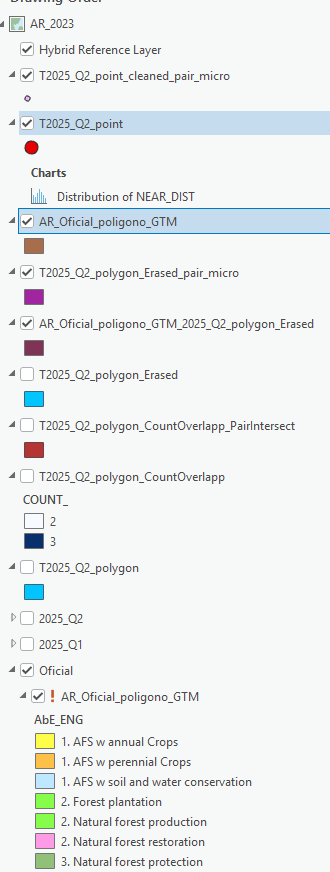


### 5.3.4 Updating: Backup for current quarter data

In [ ]:
arcpy.CopyFeatures_management(official_point, official_point_current_qt_backup)
arcpy.CopyFeatures_management(official_polygon, official_polygon_current_qt_backup)

In [ ]:
# Layer names to remove
layers_to_remove = [
    official_point_current_qt_backup,
    official_polygon_current_qt_backup
]

# Function to remove layers by name
def remove_layers_by_name(map_obj, layer_names):
    for lyr in map_obj.listLayers():
        if lyr.name in layer_names:
            map_obj.removeLayer(lyr)
            print(f"Removed layer: {lyr.name}")

# Remove the specified layers
remove_layers_by_name(map_obj, layers_to_remove)

### 5.3.5 Generate Buffer_m for Official point: only for references

In [ ]:
import os
import math

# Construct the full paths for the input point feature class and the output buffer feature class
input_fc = os.path.join(arcpy.env.workspace, official_accumulated_gdb, AR_Oficial_punto_GTM)
output_buffer_fc = os.path.join(arcpy.env.workspace, official_accumulated_gdb, AR_Oficial_punto_GTM+"_Buffer")


# Check if the "buffer_m" field exists; if not, add it
fields = [f.name for f in arcpy.ListFields(input_fc)]
if "buffer_m" not in fields:
    arcpy.AddField_management(input_fc, "buffer_m", "DOUBLE")

# Pre-calculate the buffer distance (radius in meters) from the Area_ha field.
# Calculation: radius = sqrt((Area_ha * 10000) / pi)
expression = "math.sqrt(!Area_ha! * 10000 / math.pi)"
code_block = "import math"
arcpy.CalculateField_management(input_fc, "buffer_m", expression, "PYTHON3", code_block)

# Generate the buffer polygon using the pre-calculated 'buffer_m' field as the buffer distance
arcpy.analysis.Buffer(
    in_features=input_fc,
    out_feature_class=output_buffer_fc,
    buffer_distance_or_field="buffer_m",  # This tells the tool to use the field values directly
    line_side="FULL",
    line_end_type="ROUND",
    dissolve_option="NONE",
    dissolve_field=None,
    method="PLANAR"
)

print("Buffer generation complete.")


In [ ]:
arcpy.management.ApplySymbologyFromLayer(
    in_layer="AR_Oficial_punto_GTM_Buffer",
    in_symbology_layer=r"Oficial\AR_Oficial_poligono_GTM",
    symbology_fields="VALUE_FIELD AbE_ENG AbE_ENG",
    update_symbology="DEFAULT"
)

# 6. Export table to merge table

## 6.1. Polygon
 * Export polygon feature class to table so you could merge table in the end

In [ ]:
import re

# Function to execute the main code logic
def export_fc_to_table(feature_layer):
    shape_name = feature_layer.split("\\")[-1]  # Extract the shape name from the feature layer path
    
    long_text = f"""
    Area_ha "Area_ha" true true false 8 Double 0 0,First,#,{shape_name},Area_ha,-1,-1;
    CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,{shape_name},CdgActvdd,0,254;
    AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,{shape_name},AbE_ENG,0,7999;
    OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,{shape_name},OUTPUT,0,511;
    TRATAMIENTO_OLD "TRATAMIENTO_OLD" true true false 512 Text 0 0,First,#,{shape_name},TRATAMIENTO_OLD,0,511;
    DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,{shape_name},DEPT_ID,0,4;
    MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,{shape_name},MUNI_ID,0,4;
    MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,{shape_name},MUNI_NOMBRE,0,74;
    DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,{shape_name},DEPTO_NOMBRE,0,49;
    MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,{shape_name},MICRO_NOMBRE,0,49;
    CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,{shape_name},CUENCA_NOMBRE,0,49;
    MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,{shape_name},MICRO_HA,-1,-1;
    MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,{shape_name},MICRO_ID,-1,-1;
    AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,{shape_name},AREA_TYPE_1_ESP,0,253;
    AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_2_ESP,0,254;
    AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_1_ENG,0,254;
    AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_2_ENG,0,254;
    CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,{shape_name},CUENCA_ID,-1,-1;
    AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,{shape_name},AREA_ID,-1,-1;
    TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,{shape_name},TRATAMIENTO,0,511;
    MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,{shape_name},MICRO_ID_UNIQ,-1,-1;
    MICRO_NOMBRE_OLD "MICRO_NOMBRE_OLD" true true false 512 Text 0 0,First,#,{shape_name},MICRO_NOMBRE_OLD,0,511;
    Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,{shape_name},Shp_x_center,-1,-1;
    Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,{shape_name},Shp_y_center,-1,-1;
    MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,{shape_name},MICRO_Centroid_X,-1,-1;
    MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,{shape_name},MICRO_Centroid_Y,-1,-1;
    FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,{shape_name},FECHA_DE_LA_ACTIVIDAD,-1,-1;
    CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{shape_name},CÓDIGO_DE_LA_ACTIVIDAD,0,7999;
    NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{shape_name},NOMBRE_DE_LA_ACTIVIDAD,0,7999;
    ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,{shape_name},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;
    TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,{shape_name},TIPO_DE_BOSQUE,0,7999;
    TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,{shape_name},TOTAL_DE_HECTÁREAS,-1,-1;
    COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,{shape_name},COUNTRY,0,511;
    NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,{shape_name},NÚMERO_DE_CONTRATO,0,7999;
    ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,{shape_name},ORGANIZACIÓN,0,7999;
    Revision "Revision" true true false 512 Text 0 0,First,#,{shape_name},Revision,0,511;
    Calidad_SIG "Calidad SIG" true true false 512 Text 0 0,First,#,{shape_name},Calidad_SIG,0,511;
    Agrupado "Agrupado" true true false 512 Text 0 0,First,#,{shape_name},Agrupado,0,253;
    Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,{shape_name},Num_Parcelas,-1,-1;
    Shape_Length "Shape_Length" false true true 8 Double 0 0,First,#,{shape_name},Shape_Length,-1,-1;
    Shape_Area "Shape_Area" false true true 8 Double 0 0,First,#,{shape_name},Shape_Area,-1,-1
    """
    # Regular expression pattern to find paths dynamically
    path_pattern = re.compile(rf'\b\d{{4}}_Oficial\\{shape_name}\b')

    # Split the text by semicolon
    parts = long_text.strip().split(';')

    # Define a list to hold extracted paths
    extracted_paths = []

    # Iterate over each part and search for paths
    for part in parts:
        match = path_pattern.search(part)
        if match:
            extracted_paths.append(match.group())

    # Replace extracted paths with the new base path
    new_base_path = feature_layer
    new_parts = [part.replace(path, new_base_path) for part, path in zip(parts, extracted_paths)]

    # Join the parts back into a string
    field_mappings_text = ';'.join(new_parts)

    print(field_mappings_text)  # Export Table from Updated Accumulated Official Data for Polygon

    # Export the table
    arcpy.conversion.ExportTable(
        in_table=feature_layer,
        out_table=export_table_polygon,
        where_clause="",
        use_field_alias_as_name="NOT_USE_ALIAS",
        field_mapping=field_mappings_text,
        sort_field=None
    )
    print(f"{feature_layer} exported to table as of {export_table_polygon}")

# Check which feature layer exists and eif arcpy.Exists(AR_Oficial_poligono_GTM_Erased):
official_polygon = "AR_oficial_poligonos_Q4_2025_130426_GP"
if arcpy.Exists(official_polygon):
    export_fc_to_table(official_polygon)
else:
    print("official_polygon does not exist. Skipping operations.")


## 6.2. Point

* Export point feature class to table so you could merge table in the end

In [ ]:
# Function to execute the main code logic
def export_point_to_table(feature_layer):
    shape_name = feature_layer.split("\\")[-1]  # Extract the shape name from the feature layer path

    long_text = f"""
    CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,{shape_name},CdgActvdd,0,254;
    OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,{shape_name},OUTPUT,0,511;
    Area_ha "Area_ha" true true false 8 Double 0 0,First,#,{shape_name},Area_ha,-1,-1;
    Shp_x_center "X" true true false 8 Double 0 0,First,#,{shape_name},Shp_x_center,-1,-1;
    Shp_y_center "Y" true true false 8 Double 0 0,First,#,{shape_name},Shp_y_center,-1,-1;
    MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,{shape_name},MICRO_ID_UNIQ,-1,-1;
    MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,{shape_name},MICRO_ID,-1,-1;
    MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,{shape_name},MICRO_NOMBRE,0,49;
    MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,{shape_name},MICRO_HA,-1,-1;
    MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,{shape_name},MICRO_Centroid_X,-1,-1;
    MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,{shape_name},MICRO_Centroid_Y,-1,-1;
    CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,{shape_name},CUENCA_ID,-1,-1;
    CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,{shape_name},CUENCA_NOMBRE,0,49;
    AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,{shape_name},AREA_ID,-1,-1;
    AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,{shape_name},AREA_TYPE_1_ESP,0,253;
    AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_2_ESP,0,254;
    AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_1_ENG,0,254;
    AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,{shape_name},AREA_TYPE_2_ENG,0,254;
    TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,{shape_name},TRATAMIENTO,0,511;
    MUNI_ID "COD_MUNI" true true false 5 Text 0 0,First,#,{shape_name},MUNI_ID,0,4;
    MUNI_NOMBRE "MUNI" true true false 75 Text 0 0,First,#,{shape_name},MUNI_NOMBRE,0,74;
    DEPT_ID "COD_DEPT" true true false 5 Text 0 0,First,#,{shape_name},DEPT_ID,0,4;
    DEPTO_NOMBRE "DEPTO" true true false 50 Text 0 0,First,#,{shape_name},DEPTO_NOMBRE,0,49;
    COUNTRY "PAIS" true true false 512 Text 0 0,First,#,{shape_name},COUNTRY,0,511;
    AbE_ENG "EbA_ENG" true true false 8000 Text 0 0,First,#,{shape_name},AbE_ENG,0,7999;
    FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,{shape_name},FECHA_DE_LA_ACTIVIDAD,-1,-1;
    CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{shape_name},CÓDIGO_DE_LA_ACTIVIDAD,0,7999;
    NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{shape_name},NOMBRE_DE_LA_ACTIVIDAD,0,7999;
    ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,{shape_name},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;
    TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,{shape_name},TIPO_DE_BOSQUE,0,7999;
    TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,{shape_name},TOTAL_DE_HECTÁREAS,-1,-1;
    Agrupado "Agrupado" true true false 512 Text 0 0,First,#,{shape_name},Agrupado,0,253;
    Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,{shape_name},Num_Parcelas,-1,-1;
    NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,{shape_name},NÚMERO_DE_CONTRATO,0,7999;
    ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,{shape_name},ORGANIZACIÓN,0,7999
    """

    # Regular expression pattern to find paths dynamically
    path_pattern = re.compile(rf'\b\d{{4}}_Oficial\\{shape_name}\b')

    # Split the text by semicolon
    parts = long_text.strip().split(';')

    # Define a list to hold extracted paths
    extracted_paths = []

    # Iterate over each part and search for paths
    for part in parts:
        match = path_pattern.search(part)
        if match:
            extracted_paths.append(match.group())

    # Replace extracted paths with the new base path
    new_base_path = feature_layer
    new_parts = [part.replace(path, new_base_path) for part, path in zip(parts, extracted_paths)]

    # Join the parts back into a string
    field_mappings_text = ';'.join(new_parts)

    print(field_mappings_text)  # Export Table from Updated Accumulated Official Data for Polygon

    # Export the table
    arcpy.conversion.ExportTable(
        in_table=feature_layer,
        out_table=export_table_point,
        where_clause="",
        use_field_alias_as_name="NOT_USE_ALIAS",
        field_mapping=field_mappings_text,
        sort_field=None
    )
    print(f"{feature_layer} exported to table as of {export_table_point}")

official_point = "AR_oficial_puntos_Q4_2025_130426_GP_Rev"
# Check which feature layer exists and execute the code
if arcpy.Exists(official_point):
    export_point_to_table(official_point)
else:
    print("official_point does not exist. Skipping operations.")

## 6.3. Merge Official Tables

In [ ]:
# Add a new field for the shape type in each table
arcpy.management.AddField(export_table_polygon, "Shape_Type", "TEXT", field_length=50)
arcpy.management.AddField(export_table_point, "Shape_Type", "TEXT", field_length=50)

# Calculate the shape type for each table
arcpy.management.CalculateField(export_table_polygon, "Shape_Type", '"Polygon"', "PYTHON3")
arcpy.management.CalculateField(export_table_point, "Shape_Type", '"Point"', "PYTHON3")

In [ ]:

# Define the field mappings with existing variable names and shape type column
field_mappings = f'''
Area_ha "Area_ha" true true false 8 Double 0 0,First,#,{export_table_polygon},Area_ha,-1,-1,{export_table_point},Area_ha,-1,-1;
CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,{export_table_polygon},CdgActvdd,0,254,{export_table_point},CdgActvdd,0,254;
AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,{export_table_polygon},AbE_ENG,0,7999,{export_table_point},AbE_ENG,0,7999;
OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,{export_table_polygon},OUTPUT,0,511,{export_table_point},OUTPUT,0,511;
TRATAMIENTO_OLD "TRATAMIENTO_OLD" true true false 512 Text 0 0,First,#,{export_table_polygon},TRATAMIENTO_OLD,0,511;
DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,{export_table_polygon},DEPT_ID,0,4,{export_table_point},DEPT_ID,0,4;
MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,{export_table_polygon},MUNI_ID,0,4,{export_table_point},MUNI_ID,0,4;
MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,{export_table_polygon},MUNI_NOMBRE,0,74,{export_table_point},MUNI_NOMBRE,0,74;
DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,{export_table_polygon},DEPTO_NOMBRE,0,49,{export_table_point},DEPTO_NOMBRE,0,49;
MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,{export_table_polygon},MICRO_NOMBRE,0,49,{export_table_point},MICRO_NOMBRE,0,49;
CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,{export_table_polygon},CUENCA_NOMBRE,0,49,{export_table_point},CUENCA_NOMBRE,0,49;
MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,{export_table_polygon},MICRO_HA,-1,-1,{export_table_point},MICRO_HA,-1,-1;
MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,{export_table_polygon},MICRO_ID,-1,-1,{export_table_point},MICRO_ID,-1,-1;
AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,{export_table_polygon},AREA_TYPE_1_ESP,0,253,{export_table_point},AREA_TYPE_1_ESP,0,253;
AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,{export_table_polygon},AREA_TYPE_2_ESP,0,254,{export_table_point},AREA_TYPE_2_ESP,0,254;
AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,{export_table_polygon},AREA_TYPE_1_ENG,0,254,{export_table_point},AREA_TYPE_1_ENG,0,254;
AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,{export_table_polygon},AREA_TYPE_2_ENG,0,254,{export_table_point},AREA_TYPE_2_ENG,0,254;
CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,{export_table_polygon},CUENCA_ID,-1,-1,{export_table_point},CUENCA_ID,-1,-1;
AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,{export_table_polygon},AREA_ID,-1,-1,{export_table_point},AREA_ID,-1,-1;
TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,{export_table_polygon},TRATAMIENTO,0,511,{export_table_point},TRATAMIENTO,0,511;
MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,{export_table_polygon},MICRO_ID_UNIQ,-1,-1,{export_table_point},MICRO_ID_UNIQ,-1,-1;
MICRO_NOMBRE_OLD "MICRO_NOMBRE_OLD" true true false 512 Text 0 0,First,#,{export_table_polygon},MICRO_NOMBRE_OLD,0,511;
Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,{export_table_polygon},Shp_x_center,-1,-1,{export_table_point},Shp_x_center,-1,-1;
Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,{export_table_polygon},Shp_y_center,-1,-1,{export_table_point},Shp_y_center,-1,-1;
MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,{export_table_polygon},MICRO_Centroid_X,-1,-1,{export_table_point},MICRO_Centroid_X,-1,-1;
MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,{export_table_polygon},MICRO_Centroid_Y,-1,-1,{export_table_point},MICRO_Centroid_Y,-1,-1;
FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,{export_table_polygon},FECHA_DE_LA_ACTIVIDAD,-1,-1,{export_table_point},FECHA_DE_LA_ACTIVIDAD,-1,-1;
CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{export_table_polygon},CÓDIGO_DE_LA_ACTIVIDAD,0,7999,{export_table_point},CÓDIGO_DE_LA_ACTIVIDAD,0,7999;
NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,{export_table_polygon},NOMBRE_DE_LA_ACTIVIDAD,0,7999,{export_table_point},NOMBRE_DE_LA_ACTIVIDAD,0,7999;
ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,{export_table_polygon},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999,{export_table_point},ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;
TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,{export_table_polygon},TIPO_DE_BOSQUE,0,7999,{export_table_point},TIPO_DE_BOSQUE,0,7999;
TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,{export_table_polygon},TOTAL_DE_HECTÁREAS,-1,-1,{export_table_point},TOTAL_DE_HECTÁREAS,-1,-1;
COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,{export_table_polygon},COUNTRY,0,511,{export_table_point},COUNTRY,0,511;
NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,{export_table_polygon},NÚMERO_DE_CONTRATO,0,7999,{export_table_point},NÚMERO_DE_CONTRATO,0,7999;
ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,{export_table_polygon},ORGANIZACIÓN,0,7999,{export_table_point},ORGANIZACIÓN,0,7999;
Agrupado "Agrupado" true true false 512 Text 0 0,First,#,{export_table_polygon},Agrupado,0,253,{export_table_point},Agrupado,0,253;
Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,{export_table_polygon},Num_Parcelas,-1,-1,{export_table_point},Num_Parcelas,-1,-1;
Shape_Length "Shape_Length" true true false 8 Double 0 0,First,#,{export_table_polygon},Shape_Length,-1,-1;
Shape_Area "Shape_Area" true true false 8 Double 0 0,First,#,{export_table_polygon},Shape_Area,-1,-1;
Shape "Shape" true true false 50 Text 0 0,First,#,{export_table_polygon},Shape_Type,0,49,{export_table_point},Shape_Type,0,49
'''

# Merge the layers with dynamic field mappings
arcpy.management.Merge(
    inputs=[export_table_polygon, export_table_point],
    output=export_table_merged,
    field_mappings=field_mappings,
    add_source="NO_SOURCE_INFO"
)



## 6.4. Groupby merged Official Tables

In [ ]:
import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows

database_oficial_folder = os.environ.get('EXCEL_DB_DIR')

export_table_merged_excel = f"{database_oficial_folder}\\AR_Oficial_{current_qt}_merged_shapes.xlsx"

# Define the name for the accumulated Excel file
accumulated_excel_file = f"{database_oficial_folder}\\AR_Oficial_Accumulated_merged_shapes.xlsx"


In [ ]:
# Create the directory if it doesn't exist
if not os.path.exists(database_oficial_folder):
    os.makedirs(database_oficial_folder)
    print(f"Created directory: {database_oficial_folder}")

export_table_merged_excel = os.path.join(database_oficial_folder, f"AR_Oficial_{current_qt}_merged_shapes.xlsx")

# First, let's verify the table exists and check its properties
print(f"Checking table: {export_table_merged}")
if arcpy.Exists(export_table_merged):
    # Get table properties
    desc = arcpy.Describe(export_table_merged)
    print(f"Table type: {desc.dataType}")
    
    result = arcpy.GetCount_management(export_table_merged)
    count = int(result.getOutput(0))
    print(f"Table exists with {count} records")
    
    # Get field names
    field_names = [field.name for field in arcpy.ListFields(export_table_merged)]
    print(f"Number of fields: {len(field_names)}")
    print("Field names:")
    for field_name in field_names:
        print(f"  - {field_name}")
    
    if count > 0:
        try:
            # Method 1: Use pandas to read and export the data
            print("Attempting pandas export method...")
            
            # Get data using SearchCursor
            data = []
            with arcpy.da.SearchCursor(export_table_merged, field_names) as cursor:
                for row in cursor:
                    data.append(list(row))
            
            # Create DataFrame
            df = pd.DataFrame(data, columns=field_names)
            
            # Export to Excel
            df.to_excel(export_table_merged_excel, index=False, engine='openpyxl')
            print(f"Successfully exported using pandas: {export_table_merged_excel}")
            
        except Exception as e1:
            print(f"Pandas export failed: {e1}")
            
            try:
                # Method 2: Export to CSV first, then convert to Excel
                print("Attempting CSV export method...")
                csv_file = export_table_merged_excel.replace('.xlsx', '.csv')
                
                # Use TableToTable to export to CSV
                csv_name = os.path.basename(csv_file).replace('.csv', '')
                csv_dir = os.path.dirname(csv_file)
                
                arcpy.conversion.TableToTable(
                    in_rows=export_table_merged,
                    out_path=csv_dir,
                    out_name=csv_name + ".csv"
                )
                
                # Read CSV and convert to Excel
                df_csv = pd.read_csv(csv_file)
                df_csv.to_excel(export_table_merged_excel, index=False, engine='openpyxl')
                
                # Clean up CSV file
                if os.path.exists(csv_file):
                    os.remove(csv_file)
                
                print(f"Successfully exported via CSV conversion: {export_table_merged_excel}")
                
            except Exception as e2:
                print(f"CSV export also failed: {e2}")
                
                try:
                    # Method 3: Try simplified TableToExcel
                    print("Attempting simplified TableToExcel...")
                    arcpy.conversion.TableToExcel(
                        Input_Table=export_table_merged,
                        Output_Excel_File=export_table_merged_excel
                    )
                    print(f"Successfully exported with simplified TableToExcel: {export_table_merged_excel}")
                    
                except Exception as e3:
                    print(f"All export methods failed. Final error: {e3}")
                    print("Please check:")
                    print("1. File permissions on the target directory")
                    print("2. Available disk space")
                    print("3. Whether Excel/openpyxl is properly installed")
                    print(f"4. Table path: {export_table_merged}")
    else:
        print("Table is empty - no records to export")
else:
    print(f"Table {export_table_merged} does not exist")
    print("Available tables in the geodatabase:")
    arcpy.env.workspace = os.path.dirname(export_table_merged)
    tables = arcpy.ListTables()
    for table in tables:
        print(f"  - {table}")

In [ ]:
sheet_names = pd.ExcelFile(export_table_merged_excel).sheet_names
print(sheet_names[0])


In [ ]:
sheet_name = sheet_names[0]

# Read the specified sheet into a pandas DataFrame
df = pd.read_excel(export_table_merged_excel, sheet_name=sheet_name)
df

In [ ]:
# Define aggregation methods for the fields
agg_methods = {
    'CdgActvdd': 'first',  # Keeping the first occurrence in each group
    'Area_ha': np.sum, 
    'Agrupado': 'first',
    'Num_Parcelas': np.sum, 
    'AbE_ENG': 'first',
    'OUTPUT': 'first',
    'FECHA_DE_LA_ACTIVIDAD': 'first',
    'CÓDIGO_DE_LA_ACTIVIDAD': 'first',
    'NOMBRE_DE_LA_ACTIVIDAD': 'first',
    'ACCIONES_DE_RESTAURACIÓN_AbE': 'first',
    'COUNTRY': 'first',
    'NÚMERO_DE_CONTRATO': 'first',
    'ORGANIZACIÓN': 'first',
    'Shape_Length': 'first',
    'Shape_Area': 'first',
    'Shape': 'first'
}

# Group by 'CdgActvdd' and aggregate fields based on the defined methods
aggregated_df = df.groupby('CdgActvdd', as_index=False).agg(agg_methods)

# Display the aggregated DataFrame
aggregated_df

In [ ]:
# Type of Grants를 넣어야 한다. 
# Calculate the 'Type of Grants' field based on the 'NÚMERO_DE_CONTRATO' field: if the contract number contain the word'PPD', set the value to 'Small Grant', otherwise set it to 'Medium Grant'

import numpy as np

# make sure column is string so .str methods won't fail
aggregated_df['NÚMERO_DE_CONTRATO'] = aggregated_df['NÚMERO_DE_CONTRATO'].astype(str)

# Apply conditional logic
aggregated_df['Type of Grants'] = np.where(
    aggregated_df['NÚMERO_DE_CONTRATO'].str.contains('PPD', case=False, na=False),
    'small',
    np.where(
        aggregated_df['NÚMERO_DE_CONTRATO'].str.contains('PMD', case=False, na=False),
        'medium',
        None  # leave empty when no match
    )
)
aggregated_df


In [ ]:
import os
from openpyxl import load_workbook

# 1. DataFrame 크기
print(f"DataFrame: {df.shape[0]} filas, {df.shape[1]} columnas")

# 2. Excel 파일 크기
size_mb = os.path.getsize(accumulated_excel_file) / (1024 * 1024)
print(f"Excel file: {size_mb:.2f} MB")

# 3. 기존 시트 정보
book = load_workbook(accumulated_excel_file, read_only=True)
print(f"Total sheets: {len(book.sheetnames)}")
sheet_name = f'MergedShapes_{current_qt}'
if sheet_name in book.sheetnames:
    sheet = book[sheet_name]
    print(f"Sheet '{sheet_name}' existe: dimensiones {sheet.dimensions}")
else:
    print(f"Sheet '{sheet_name}' no existe (nuevo)")
book.close()

In [ ]:
def add_df_to_excel(filename, df, sheet_name):
    book = load_workbook(filename)
    
    # Create a new sheet or get the existing one
    if sheet_name in book.sheetnames:
        sheet = book[sheet_name]
        for row in sheet[sheet.dimensions]:
            for cell in row:
                cell.value = None
    else:
        sheet = book.create_sheet(sheet_name)
    
    # Write the DataFrame to the sheet
    for r in dataframe_to_rows(df, index=False, header=True):
        sheet.append(r)
    
    book.save(filename)

# Add the first DataFrame
add_df_to_excel(accumulated_excel_file, df, f'MergedShapes_{current_qt}')

In [ ]:
# Add the second DataFrame
add_df_to_excel(accumulated_excel_file, aggregated_df, f'GroupbyCdg_{current_qt}')


In [ ]:
# Optionally, list the sheet names in the updated Excel file
with pd.ExcelFile(accumulated_excel_file, engine='openpyxl') as xls:
    sheet_names = xls.sheet_names
print(f"Sheet names in the accumulated Excel file: {sheet_names}")

In [ ]:
sheet_names = pd.ExcelFile(accumulated_excel_file).sheet_names
print(sheet_names)

In [ ]:
sheet_name = sheet_names[-1]

# Read the specified sheet into a pandas DataFrame
df_shp_groupby_cdg = pd.read_excel(accumulated_excel_file, sheet_name=sheet_name)
df_shp_groupby_cdg

In [ ]:
# Smartsheet data into Dataframe

fields = [field.name for field in arcpy.ListFields(ssheet)]
ssheet_data = []

with arcpy.da.SearchCursor(ssheet, fields) as cursor:
    for row in cursor:
        row_dict = {field: value for field, value in zip(fields, row)}
        ssheet_data.append(row_dict)
        
ssdf = pd.DataFrame(ssheet_data)
ssdf

In [ ]:
import pandas as pd

# Assuming gis and ss are your two DataFrames
# gis (df1) and ss (df2)

# Ensure both DataFrames have the required columns
required_columns_df1 = ['CÓDIGO_DE_LA_ACTIVIDAD', 'Area_ha']
required_columns_df2 = ['CÓDIGO_DE_LA_ACTIVIDAD', 'TOTAL_DE_HECTÁREAS']
assert all(col in df_shp_groupby_cdg.columns for col in required_columns_df1), "df_shp_groupby_cdg does not have the required columns"
assert all(col in ssdf.columns for col in required_columns_df2), "ssdf does not have the required columns"

# Rename the 'TOTAL_DE_HECTÁREAS' column in ssdf to 'Area_ha' for consistency
ss_renamed = ssdf.rename(columns={'TOTAL_DE_HECTÁREAS': 'Area_ha'})

# Merge the DataFrames on 'CÓDIGO_DE_LA_ACTIVIDAD'
merged_df = pd.merge(df_shp_groupby_cdg, ss_renamed, on='CÓDIGO_DE_LA_ACTIVIDAD', suffixes=('_gis', '_ss'))

# Compare the 'Area_ha' columns
merged_df['Areas_Equal'] = merged_df['Area_ha_gis'] == merged_df['Area_ha_ss']

# Summarize the comparison results
all_areas_equal = merged_df['Areas_Equal'].all()

print("Comparison Results:")
print(merged_df)
print(f"All Areas Equal: {all_areas_equal}")

# Identify mismatched rows
mismatched_rows = merged_df[~merged_df['Areas_Equal']]

# Calculate the difference and round to 2 decimal places
mismatched_rows['diff'] = (mismatched_rows['Area_ha_gis'] - mismatched_rows['Area_ha_ss']).round(2)

# Select and display the relevant columns
print(mismatched_rows[['CÓDIGO_DE_LA_ACTIVIDAD', 'Area_ha_gis', 'Area_ha_ss', 'diff']])


In [ ]:
# Filter rows where 'diff' is non-zero
non_zero_diff_rows = mismatched_rows[mismatched_rows['diff'] != 0]

# Sort the filtered rows by 'diff'
non_zero_diff_rows[['CÓDIGO_DE_LA_ACTIVIDAD', 'Area_ha_gis', 'Area_ha_ss', 'diff']].sort_values(by='diff')

non_zero_diff_rows


In [ ]:
compare_sig_ssmart = f"{database_oficial_folder}\\AR_Oficial_compare.xlsx"

add_df_to_excel(compare_sig_ssmart, non_zero_diff_rows, f'{current_qt}_non_zero')

### After updating excel file, you should turn off your ArcGIS Pro (python environment to be set free your excel file from the lock so that you can edit Pivot table on the first page of excel)

# 7. Update WFL using GDB


In [ ]:
import sys
import os
import arcpy
import atexit
import re

def setup_environment():
    """Sets up the arcpy environment for use in scripts using global paths."""
    try:
        arcpy.env.workspace = os.environ.get('workspace_path')
        arcpy.env.overwriteOutput = True
        atexit.register(arcpy.ClearWorkspaceCache_management)
        print("Environment set up with workspace:", arcpy.env.workspace)
    except Exception as e:
        print("Failed to set up environment:", e)

def get_map_object(map_name="AR_Official WebMap"):
    """Retrieves a map object from the global APRX path."""
    try:
        aprx = arcpy.mp.ArcGISProject(aprx_path)
        map_obj = aprx.listMaps(map_name)[0]
        print(f"Map object retrieved successfully.: {map_name}")
        return map_obj
    except Exception as e:
        print("Failed to retrieve map object:", e)
        return None

# Setup environment and get the map object
setup_environment()
map_obj = get_map_object()
if map_obj:
    print(f"Map object retrieved successfully.")
else:
    print("Failed to retrieve map object.")


## 7.1.1. `Point`: select by location using `Are identical to` relationship, 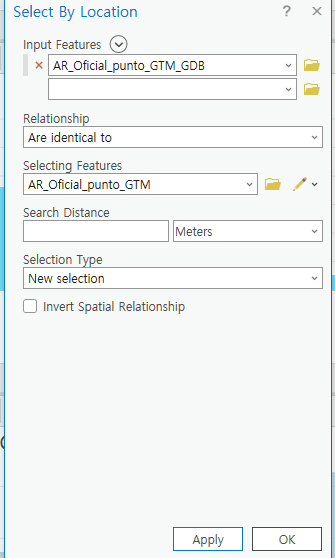

In [ ]:
# Define input feature layer and selecting feature layer
input_features = "Oficial_GDB\AR_Oficial_punto_GTM_GDB"
selecting_features = "Oficial_WFL\AR_Oficial_punto_GTM_WFL"

# Perform Select By Location
arcpy.management.SelectLayerByLocation(
    in_layer=input_features, 
    overlap_type="ARE_IDENTICAL_TO", 
    select_features=selecting_features, 
    selection_type="NEW_SELECTION"
)

print("Selection completed.")


## 7.1.2 then convert the selection to get `NEW` data only 

In [ ]:

# Switch selection
arcpy.management.SelectLayerByAttribute(input_features, "SWITCH_SELECTION")

print("Selection switched successfully.")


## 7.1.3 then append the selection as `NEW` data to WFL

In [ ]:
arcpy.management.Append(
    inputs=r"Oficial_GDB\AR_Oficial_punto_GTM_GDB",
    target=r"Oficial_WFL\AR_Oficial_punto_GTM_WFL",
    schema_type="NO_TEST",
    field_mapping=r'CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,CdgActvdd,0,254;OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,OUTPUT,0,511;Area_ha "Area_ha" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Area_ha,-1,-1;MICRO_ID "MICRO_ID" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_ID,-1,-1;MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_NOMBRE,0,49;CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,CUENCA_NOMBRE,0,49;AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AREA_TYPE_1_ESP,0,253;AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AREA_TYPE_2_ESP,0,254;TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,TRATAMIENTO,0,511;MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MUNI_NOMBRE,0,74;DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,DEPTO_NOMBRE,0,49;AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AbE_ENG,0,7999;FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 1,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,FECHA_DE_LA_ACTIVIDAD,-1,-1;NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,NOMBRE_DE_LA_ACTIVIDAD,0,7999;ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,TIPO_DE_BOSQUE,0,7999;TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,TOTAL_DE_HECTÁREAS,-1,-1;NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,NÚMERO_DE_CONTRATO,0,7999;ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,ORGANIZACIÓN,0,7999;MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_ID_UNIQ,-1,-1;MICRO_HA "MICRO_HA" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_HA,-1,-1;MICRO_Centroid_X "MICRO_Centroid_X" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_Centroid_X,-1,-1;MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MICRO_Centroid_Y,-1,-1;CUENCA_ID "CUENCA_ID" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,CUENCA_ID,-1,-1;AREA_ID "AREA_ID" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AREA_ID,-1,-1;AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AREA_TYPE_1_ENG,0,254;AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,AREA_TYPE_2_ENG,0,254;MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,MUNI_ID,0,4;DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,DEPT_ID,0,4;COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,COUNTRY,0,511;Shp_x_center "Shp_x_center" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Shp_x_center,-1,-1;Shp_y_center "Shp_y_center" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Shp_y_center,-1,-1;CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,CÓDIGO_DE_LA_ACTIVIDAD,0,7999;Agupados "Agupados" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Agupados,0,511;Num_Parcelas "Num_Parcelas" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Num_Parcelas,-1,-1;Shapes "Shapes" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,Shapes,0,511;buffer_m "buffer_m" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM,buffer_m,-1,-1;GlobalID "GlobalID" false false true 38 GlobalID 0 0,First,#',
    subtype="",
    expression="",
    match_fields=None,
    update_geometry="NOT_UPDATE_GEOMETRY"
)

In [ ]:
arcpy.management.CopyFeatures(
    in_features=r"Oficial_WFL\AR_Oficial_punto_GTM_WFL",
    out_feature_class=r"C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_punto_GTM",
    config_keyword="",
    spatial_grid_1=None,
    spatial_grid_2=None,
    spatial_grid_3=None
)

## 7.2.1 Select Polygon but NOT select by location

In [ ]:
# Define input feature layer and selecting feature layer
input_features_polygon = "Oficial_GDB\AR_Oficial_poligono_GTM_GDB"
selecting_features_polygon = "Oficial_WFL\AR_Oficial_poligono_GTM_WFL"

# Perform Select By Location
arcpy.management.SelectLayerByLocation(
    in_layer=input_features_polygon, 
    overlap_type="ARE_IDENTICAL_TO", 
    select_features=selecting_features_polygon, 
    selection_type="NEW_SELECTION"
)

print("Selection completed.")


In [ ]:
# Switch selection
arcpy.management.SelectLayerByAttribute(input_features_polygon, "SWITCH_SELECTION")

print("Selection switched successfully.")


In [ ]:
arcpy.management.Append(
    inputs=r"Oficial_GDB\AR_Oficial_poligono_GTM_GDB",
    target=r"Oficial_WFL\AR_Oficial_poligono_GTM_WFL",
    schema_type="NO_TEST",
    field_mapping=r'CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,CdgActvdd,0,254;OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,OUTPUT,0,511;ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,ORGANIZACIÓN,0,7999;Area_ha "Area_ha" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Area_ha,-1,-1;ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AbE_ENG,0,7999;DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,DEPT_ID,0,4;MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MUNI_ID,0,4;MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MUNI_NOMBRE,0,74;DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,DEPTO_NOMBRE,0,49;MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_NOMBRE,0,49;CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,CUENCA_NOMBRE,0,49;MICRO_HA "MICRO_HA" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_HA,-1,-1;MICRO_ID "MICRO_ID" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_ID,-1,-1;AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AREA_TYPE_1_ESP,0,253;AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AREA_TYPE_2_ESP,0,254;AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AREA_TYPE_1_ENG,0,254;AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AREA_TYPE_2_ENG,0,254;CUENCA_ID "CUENCA_ID" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,CUENCA_ID,-1,-1;AREA_ID "AREA_ID" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,AREA_ID,-1,-1;TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,TRATAMIENTO,0,511;MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_ID_UNIQ,-1,-1;Shp_x_center "Shp_x_center" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Shp_x_center,-1,-1;Shp_y_center "Shp_y_center" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Shp_y_center,-1,-1;MICRO_Centroid_X "MICRO_Centroid_X" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_Centroid_X,-1,-1;MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,MICRO_Centroid_Y,-1,-1;FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 1,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,FECHA_DE_LA_ACTIVIDAD,-1,-1;CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,CÓDIGO_DE_LA_ACTIVIDAD,0,7999;NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,NOMBRE_DE_LA_ACTIVIDAD,0,7999;TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,TIPO_DE_BOSQUE,0,7999;TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 0 Double 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,TOTAL_DE_HECTÁREAS,-1,-1;COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,COUNTRY,0,511;NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,NÚMERO_DE_CONTRATO,0,7999;Shapes "Shapes" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Shapes,0,511;Agrupado "Agrupado" true true false 512 Text 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Agrupado,0,511;Num_Parcelas "Num_Parcelas" true true false 0 Short 0 0,First,#,C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\문서\ArcGIS\Packages\ShapesFinales_C1_54b09e\AR_Oficial_Acumulado.gdb\AR_Oficial_poligono_GTM,Num_Parcelas,-1,-1;GlobalID "GlobalID" false false true 38 GlobalID 0 0,First,#',
    subtype="",
    expression="",
    match_fields=None,
    update_geometry="NOT_UPDATE_GEOMETRY"
)

In [ ]:
# Create a feature layer from CountOverlappPairIntersect

arcpy.MakeFeatureLayer_management("T2024_APR_2_polygon_CountOverlapp_PairIntersect", erase_tool_layer)

# Perform the selection on the layer
query = "Erase_FC = 'Official'"
arcpy.SelectLayerByAttribute_management(erase_tool_layer, "NEW_SELECTION", query)

# Export the selected features to a new feature class (temporary)
selected_erase_features = arcpy.management.CopyFeatures(erase_tool_layer, "in_memory/selectedEraseFeatures")

In [ ]:
input_layer = "Oficial_WFL\AR_Oficial_poligono_GTM"

# Ensure input is a layer (if not already)
if not arcpy.Describe(input_layer).FIDSet:
    arcpy.MakeFeatureLayer_management(input_layer, "temp_layer")
    input_layer = "temp_layer"

# Select features to erase
erase_features = "selectedEraseFeatures"
arcpy.management.SelectLayerByLocation(
    in_layer=input_layer,
    overlap_type="ARE_IDENTICAL_TO",  # Modify if needed
    select_features=erase_features,
    selection_type="NEW_SELECTION"
)


In [ ]:

# Delete the selected features (modifies the online WFL)
arcpy.management.DeleteFeatures(input_layer)

print("Selected features erased (deleted) successfully from the Web Feature Layer.")


# Optionally, delete the temporary feature class if no longer needed
arcpy.Delete_management("in_memory/selectedEraseFeatures")

In [ ]:
arcpy.management.CalculateGeometryAttributes(
    in_features=r"Oficial_WFL\AR_Oficial_poligono_GTM",
    geometry_property="Area_ha AREA",
    length_unit="",
    area_unit="HECTARES",
    coordinate_system='PROJCS["GTM",GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-90.5],PARAMETER["Scale_Factor",0.9998],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0]]',
    coordinate_format="SAME_AS_INPUT"
)

## 7.1.2 Copy official_erased and Rename it as official in `Catalog` > `AR_Oficial_Acumulado.gdb`

1. Copy `official_current_quarter_erased` and it will looks like `official_current_quarter_erased_1` 

2. then, Rename `AR_Oficial_poligono_GTM` as `AR_Oficial_poligono_GTM_prev`

3. then, Rename `official_current_quarter_erased` as `AR_Oficial_poligono_GTM`

4. then, Rename `official_current_quarter_erased_1` as `official_current_quarter_erased`


### 7.1.3 Apply `Symbology` using predefined color scheme & `Unique Values`


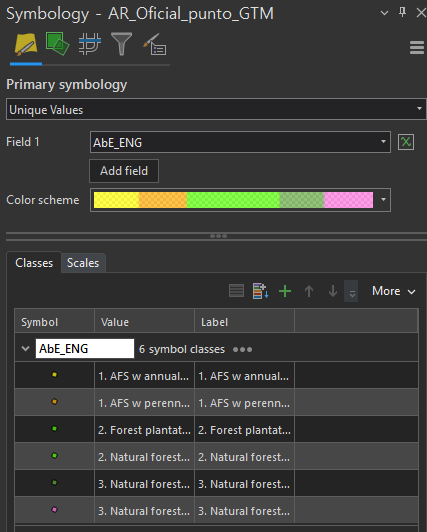

### 7.1.4 overwrite web feature layer 

1. Before overwrite wfl, please backup previous wfl using previous quarter name

1. Overwrite `AR_oficial_poligono_GTM'

2. Overwrite `AR_Oficial_punto_GTM'

## 7.2. If you are for sure with everything, 

then delete `backup fc`s and `prev fc` in gdb 

# 8 Export feature class to shape

In [ ]:
area_database_oficial_folder = r"C:\Users\yuny\OneDrive - IUCN International Union for Conservation of Nature\AR_3_Area\13. Shapes 2025"
export_polygon_to_shp = f"{area_database_oficial_folder}\\{current_qt}_Polygon.shp"
export_point_to_shp = f"{area_database_oficial_folder}\\{current_qt}_Point.shp"

In [ ]:
arcpy.conversion.ExportFeatures(
    in_features=r"Oficial\AR_Oficial_poligono_GTM",
    out_features=export_polygon_to_shp,
    where_clause="",
    use_field_alias_as_name="NOT_USE_ALIAS",
    field_mapping=r'Area_ha "Area_ha" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Area_ha,-1,-1;CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,CdgActvdd,0,254;AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AbE_ENG,0,7999;OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,OUTPUT,0,511;DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,DEPT_ID,0,4;MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MUNI_ID,0,4;MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MUNI_NOMBRE,0,74;DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,DEPTO_NOMBRE,0,49;MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_NOMBRE,0,49;CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,CUENCA_NOMBRE,0,49;MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_HA,-1,-1;MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_ID,-1,-1;AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AREA_TYPE_1_ESP,0,253;AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AREA_TYPE_2_ESP,0,254;AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AREA_TYPE_1_ENG,0,254;AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AREA_TYPE_2_ENG,0,254;CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,CUENCA_ID,-1,-1;AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,AREA_ID,-1,-1;TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,TRATAMIENTO,0,511;MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_ID_UNIQ,-1,-1;Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Shp_x_center,-1,-1;Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Shp_y_center,-1,-1;MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_Centroid_X,-1,-1;MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MICRO_Centroid_Y,-1,-1;FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,FECHA_DE_LA_ACTIVIDAD,-1,-1;CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,CÓDIGO_DE_LA_ACTIVIDAD,0,7999;NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,NOMBRE_DE_LA_ACTIVIDAD,0,7999;ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,TIPO_DE_BOSQUE,0,7999;TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,TOTAL_DE_HECTÁREAS,-1,-1;COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,COUNTRY,0,511;NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,NÚMERO_DE_CONTRATO,0,7999;ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,ORGANIZACIÓN,0,7999;Shapes "Shapes" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Shapes,0,511;Agrupado "Agrupado" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Agrupado,0,511;Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Num_Parcelas,-1,-1;F2020___MONTO_DEL_INCENTIVO__QQ_ "2020 | MONTO DEL INCENTIVO (QQ)" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2020___MONTO_DEL_INCENTIVO__QQ_,0,7999;F2021___MONTO_DEL_INCENTIVO__QQ_ "2021 | MONTO DEL INCENTIVO (QQ)" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2021___MONTO_DEL_INCENTIVO__QQ_,-1,-1;F2022___MONTO_DEL_INCENTIVO__QQ_ "2022 | MONTO DEL INCENTIVO (QQ)" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2022___MONTO_DEL_INCENTIVO__QQ_,-1,-1;F2023___MONTO_DEL_INCENTIVO__QQ_ "2023 | MONTO DEL INCENTIVO (QQ)" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2023___MONTO_DEL_INCENTIVO__QQ_,-1,-1;F2024___MONTO_DEL_INCENTIVO__QQ_ "2024 | MONTO DEL INCENTIVO (QQ)" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2024___MONTO_DEL_INCENTIVO__QQ_,-1,-1;F2025___MONTO_DEL_INCENTIVO__QQ_ "2025 | MONTO DEL INCENTIVO (QQ)" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2025___MONTO_DEL_INCENTIVO__QQ_,0,7999;F2026___MONTO_DEL_INCENTIVO__QQ_ "2026 | MONTO DEL INCENTIVO (QQ)" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,F2026___MONTO_DEL_INCENTIVO__QQ_,0,7999;MONTO_DEL_INCENTIVO__QQ_ "MONTO DEL INCENTIVO (QQ)" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,MONTO_DEL_INCENTIVO__QQ_,-1,-1;sum_monto_incentivo "sum_monto_incentivo" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,sum_monto_incentivo,-1,-1;monto_difference "monto_difference" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,monto_difference,-1,-1;Shape_Length "Shape_Length" false true true 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Shape_Length,-1,-1;Shape_Area "Shape_Area" false true true 8 Double 0 0,First,#,Oficial\AR_Oficial_poligono_GTM,Shape_Area,-1,-1',
    sort_field=None
)

In [ ]:
arcpy.conversion.ExportFeatures(
    in_features=r"Oficial\AR_Oficial_punto_GTM",
    out_features=export_point_to_shp,
    where_clause="",
    use_field_alias_as_name="NOT_USE_ALIAS",
    field_mapping=r'CdgActvdd "CdgActvdd" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,CdgActvdd,0,254;OUTPUT "OUTPUT" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,OUTPUT,0,511;MICRO_ID_UNIQ "MICRO_ID_UNIQ" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_ID_UNIQ,-1,-1;MICRO_ID "MICRO_ID" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_ID,-1,-1;MICRO_NOMBRE "MICRO_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_NOMBRE,0,49;MICRO_HA "MICRO_HA" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_HA,-1,-1;MICRO_Centroid_X "MICRO_Centroid_X" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_Centroid_X,-1,-1;MICRO_Centroid_Y "MICRO_Centroid_Y" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MICRO_Centroid_Y,-1,-1;CUENCA_ID "CUENCA_ID" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_punto_GTM,CUENCA_ID,-1,-1;CUENCA_NOMBRE "CUENCA_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,CUENCA_NOMBRE,0,49;AREA_ID "AREA_ID" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AREA_ID,-1,-1;AREA_TYPE_1_ESP "TIPO_DE_AREA_1" true true false 254 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AREA_TYPE_1_ESP,0,253;AREA_TYPE_2_ESP "TIPO_DE_AREA_2" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AREA_TYPE_2_ESP,0,254;AREA_TYPE_1_ENG "TIPO_DE_AREA_1_ENG" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AREA_TYPE_1_ENG,0,254;AREA_TYPE_2_ENG "TIPO_DE_AREA_2_ENG" true true false 255 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AREA_TYPE_2_ENG,0,254;TRATAMIENTO "TRATAMIENTO" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,TRATAMIENTO,0,511;MUNI_ID "MUNI_ID" true true false 5 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MUNI_ID,0,4;MUNI_NOMBRE "MUNI_NOMBRE" true true false 75 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,MUNI_NOMBRE,0,74;DEPT_ID "DEPT_ID" true true false 5 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,DEPT_ID,0,4;DEPTO_NOMBRE "DEPTO_NOMBRE" true true false 50 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,DEPTO_NOMBRE,0,49;COUNTRY "COUNTRY" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,COUNTRY,0,511;AbE_ENG "AbE_ENG" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,AbE_ENG,0,7999;FECHA_DE_LA_ACTIVIDAD "FECHA DE LA ACTIVIDAD" true true false 8 Date 0 0,First,#,Oficial\AR_Oficial_punto_GTM,FECHA_DE_LA_ACTIVIDAD,-1,-1;Shp_x_center "Shp_x_center" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Shp_x_center,-1,-1;Shp_y_center "Shp_y_center" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Shp_y_center,-1,-1;CÓDIGO_DE_LA_ACTIVIDAD "CÓDIGO DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,CÓDIGO_DE_LA_ACTIVIDAD,0,7999;TOTAL_DE_HECTÁREAS "TOTAL DE HECTÁREAS" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,TOTAL_DE_HECTÁREAS,-1,-1;Agupados "Agupados" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Agupados,0,511;Num_Parcelas "Num_Parcelas" true true false 2 Short 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Num_Parcelas,-1,-1;NOMBRE_DE_LA_ACTIVIDAD "NOMBRE DE LA ACTIVIDAD" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,NOMBRE_DE_LA_ACTIVIDAD,0,7999;ACCIONES_DE_RESTAURACIÓN_AbE "ACCIONES DE RESTAURACIÓN AbE" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,ACCIONES_DE_RESTAURACIÓN_AbE,0,7999;TIPO_DE_BOSQUE "TIPO DE BOSQUE" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,TIPO_DE_BOSQUE,0,7999;NÚMERO_DE_CONTRATO "NÚMERO DE CONTRATO" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,NÚMERO_DE_CONTRATO,0,7999;ORGANIZACIÓN "ORGANIZACIÓN" true true false 8000 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,ORGANIZACIÓN,0,7999;Shapes "Shapes" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Shapes,0,511;buffer_m "buffer_m" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,buffer_m,-1,-1;Area_ha "Area_ha" true true false 8 Double 0 0,First,#,Oficial\AR_Oficial_punto_GTM,Area_ha,-1,-1;JoinFieldShp "JoinFieldShp" true true false 512 Text 0 0,First,#,Oficial\AR_Oficial_punto_GTM,JoinFieldShp,0,511',
    sort_field=None
)